## Data description

link: https://docs.google.com/document/d/1X2GbykWLQlnttuWn8yi8y_jkvNyixsIJT8VYAbNi_2c/edit?usp=sharing


###  CSV Data Summary (saved fields, units, physical meaning)

| CSV File | Column | Unit | Physical Meaning |
|---|---|---|---|
| `PointCloud_snr.csv` | `timestamp_s` | s | Time from start of capture/frame timeline |
| `PointCloud_snr.csv` | `frame_number` | index | Radar frame ID |
| `PointCloud_snr.csv` | `point_index` | index | Detection ID inside a frame |
| `PointCloud_snr.csv` | `x` | m | Lateral coordinate in sensor Cartesian frame |
| `PointCloud_snr.csv` | `y` | m | Forward/depth coordinate from sensor |
| `PointCloud_snr.csv` | `z` | m | Vertical coordinate (height) |
| `PointCloud_snr.csv` | `doppler` | m/s | Radial velocity of detection (sign indicates direction) |
| `PointCloud_snr.csv` | `range` | m | Radial distance from sensor |
| `PointCloud_snr.csv` | `aoa` | degree | Estimated angle of arrival |
| `PointCloud_snr.csv` | `snr` | dB | Signal-to-noise ratio of detection |
| `PointCloud_snr.csv` | `noise` | dB (sensor scale) | Background noise estimate near detection |
| `range_doppler.csv` | `timestamp_s` | s | Time of frame |
| `range_doppler.csv` | `frame_number` | index | Radar frame ID |
| `range_doppler.csv` | `range_bin` | bin index | Discrete distance-bin location in FFT grid |
| `range_doppler.csv` | `doppler_bin` | bin index | Discrete velocity-bin location in FFT grid |
| `range_doppler.csv` | `signal_strength` | power/counts (arb.) | Return energy/intensity at (`range_bin`, `doppler_bin`) |


In [4]:
from pathlib import Path
import pandas as pd


def first_existing_dir(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_dir():
            return p
    return None


def first_existing_file(parent: Path, names):
    for name in names:
        p = parent / name
        if p.exists() and p.is_file():
            return p
    return None


def find_root(start: Path) -> Path:
    markers = ["Single Activity", "Single Activity Data", "Multipersonal Activity", "Multi personal activity"]
    for base in [start, *start.parents]:
        if any((base / m).exists() for m in markers):
            return base
    return start


def session_summary_table(dataset_root: Path, dataset_label: str) -> pd.DataFrame:
    data_root = first_existing_dir(dataset_root, ["3D data", "3D", "3d data", "3d"])
    if data_root is None:
        return pd.DataFrame(columns=["activity", "sample", "range_doppler_shape", "pointcloud_shape", "n_frames"])

    rows = []
    for activity_dir in sorted([d for d in data_root.iterdir() if d.is_dir()]):
        for sample_dir in sorted([d for d in activity_dir.iterdir() if d.is_dir()]):
            rd_path = sample_dir / "range_doppler.csv"
            pc_path = first_existing_file(sample_dir, ["PointCloud_snr.csv", "point_cloud_snr.csv", "points_cloud_snr.csv"])

            rd_shape = "missing"
            pc_shape = "missing"
            n_frames = 0

            if rd_path.exists():
                rd_df = pd.read_csv(rd_path)
                rd_shape = f"{rd_df.shape[0]} x {rd_df.shape[1]}"
                if "frame_number" in rd_df.columns:
                    n_frames = int(pd.to_numeric(rd_df["frame_number"], errors="coerce").dropna().astype(int).nunique())
                else:
                    n_frames = int(len(rd_df))

            if pc_path is not None:
                pc_df = pd.read_csv(pc_path)
                pc_shape = f"{pc_df.shape[0]} x {pc_df.shape[1]}"

            rows.append({
                "activity": activity_dir.name,
                "sample": sample_dir.name,
                "range_doppler_shape": rd_shape,
                "pointcloud_shape": pc_shape,
                "n_frames": n_frames,
            })

    out = pd.DataFrame(rows).sort_values(["activity", "sample"]).reset_index(drop=True)
    print(f"{dataset_label}: {len(out)} sessions")
    return out


research_root = find_root(Path.cwd())
single_root = first_existing_dir(research_root, ["Single Activity", "Single Activity Data"])
multi_root = first_existing_dir(research_root, ["Multipersonal Activity", "Multi personal activity", "Multi-personal Activity"])

if single_root is None:
    raise FileNotFoundError("Single Activity folder not found")
if multi_root is None:
    raise FileNotFoundError("Multipersonal Activity folder not found")

single_summary_table = session_summary_table(single_root, "Single Activity")
multi_summary_table = session_summary_table(multi_root, "Multipersonal Activity")

print("\nSingle Activity Summary")
display(single_summary_table)

print("Multipersonal Activity Summary")
display(multi_summary_table)

Single Activity: 20 sessions
Multipersonal Activity: 25 sessions

Single Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Sitting,1 m,1196032 x 5,401 x 11,146
1,Sitting,2 m,1089536 x 5,292 x 11,133
2,Sitting,3 m,1024000 x 5,151 x 11,125
3,Sitting,4 m,1122304 x 5,152 x 11,137
4,Sitting,5 m,1146880 x 5,159 x 11,140
5,Standing,1 m,1155072 x 5,301 x 11,141
6,Standing,2 m,1163264 x 5,316 x 11,142
7,Standing,3 m,1146880 x 5,201 x 11,140
8,Standing,4 m,1097728 x 5,181 x 11,134
9,Standing,5 m,1318912 x 5,193 x 11,161


Multipersonal Activity Summary


,activity,sample,range_doppler_shape,pointcloud_shape,n_frames
0,Approaching,1 m,827392 x 5,663 x 11,101
1,Approaching,2 m,892928 x 5,632 x 11,109
2,Approaching,2.5 m,745472 x 5,631 x 11,91
3,Approaching,3 m,720896 x 5,614 x 11,88
4,Approaching,4 m,860160 x 5,700 x 11,105
5,Sitting,1 m,1187840 x 5,650 x 11,145
6,Sitting,2 m,1286144 x 5,785 x 11,157
7,Sitting,2.5 m,1359872 x 5,881 x 11,166
8,Sitting,3 m,1449984 x 5,1047 x 11,177
9,Sitting,4 m,1220608 x 5,879 x 11,149


### EDA

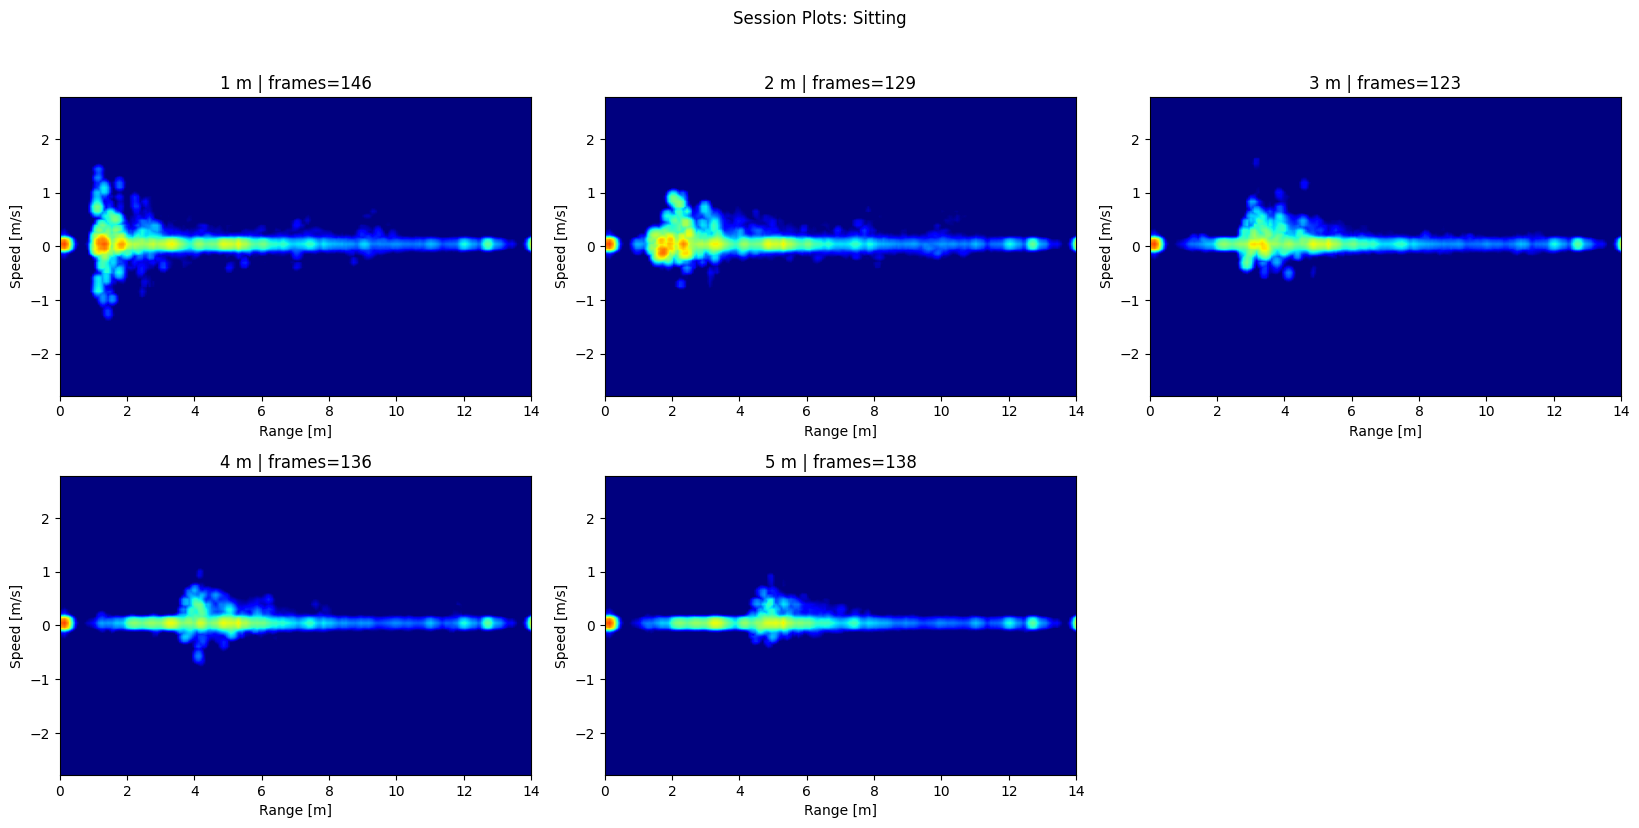

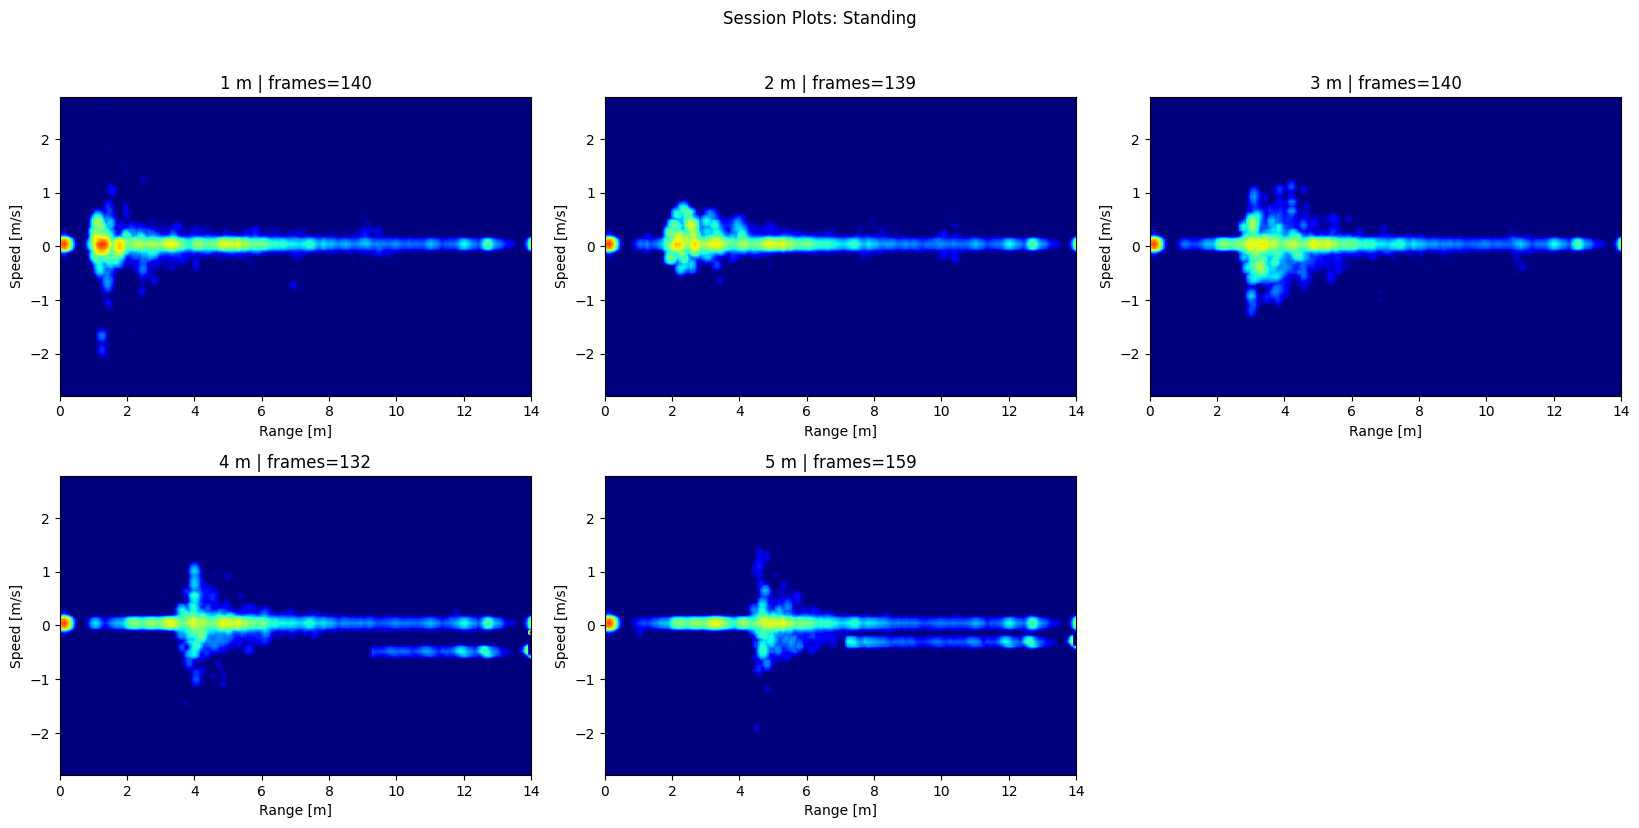

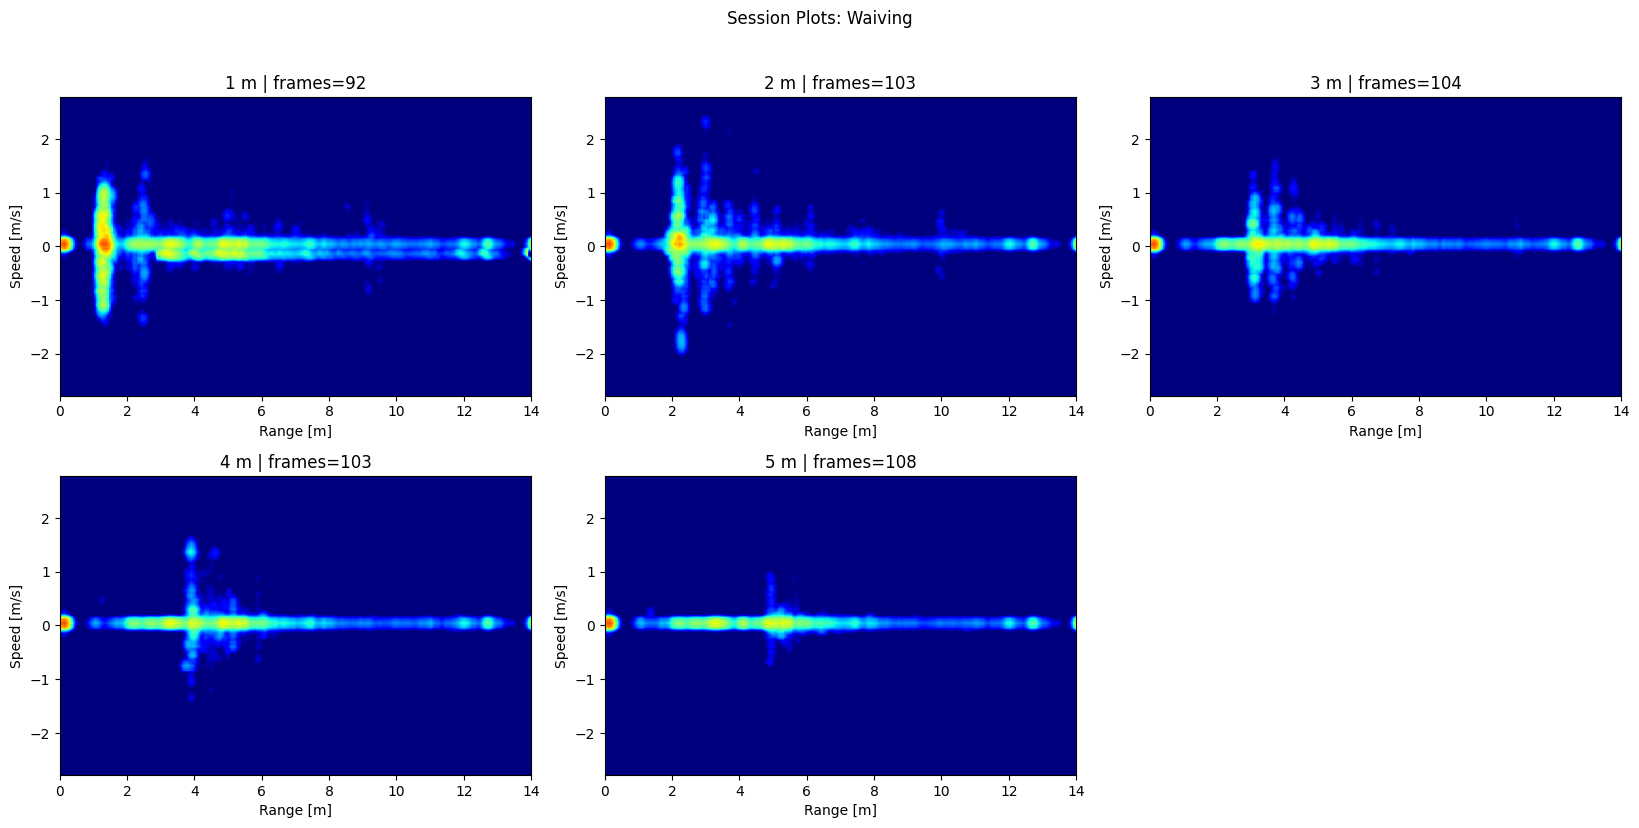

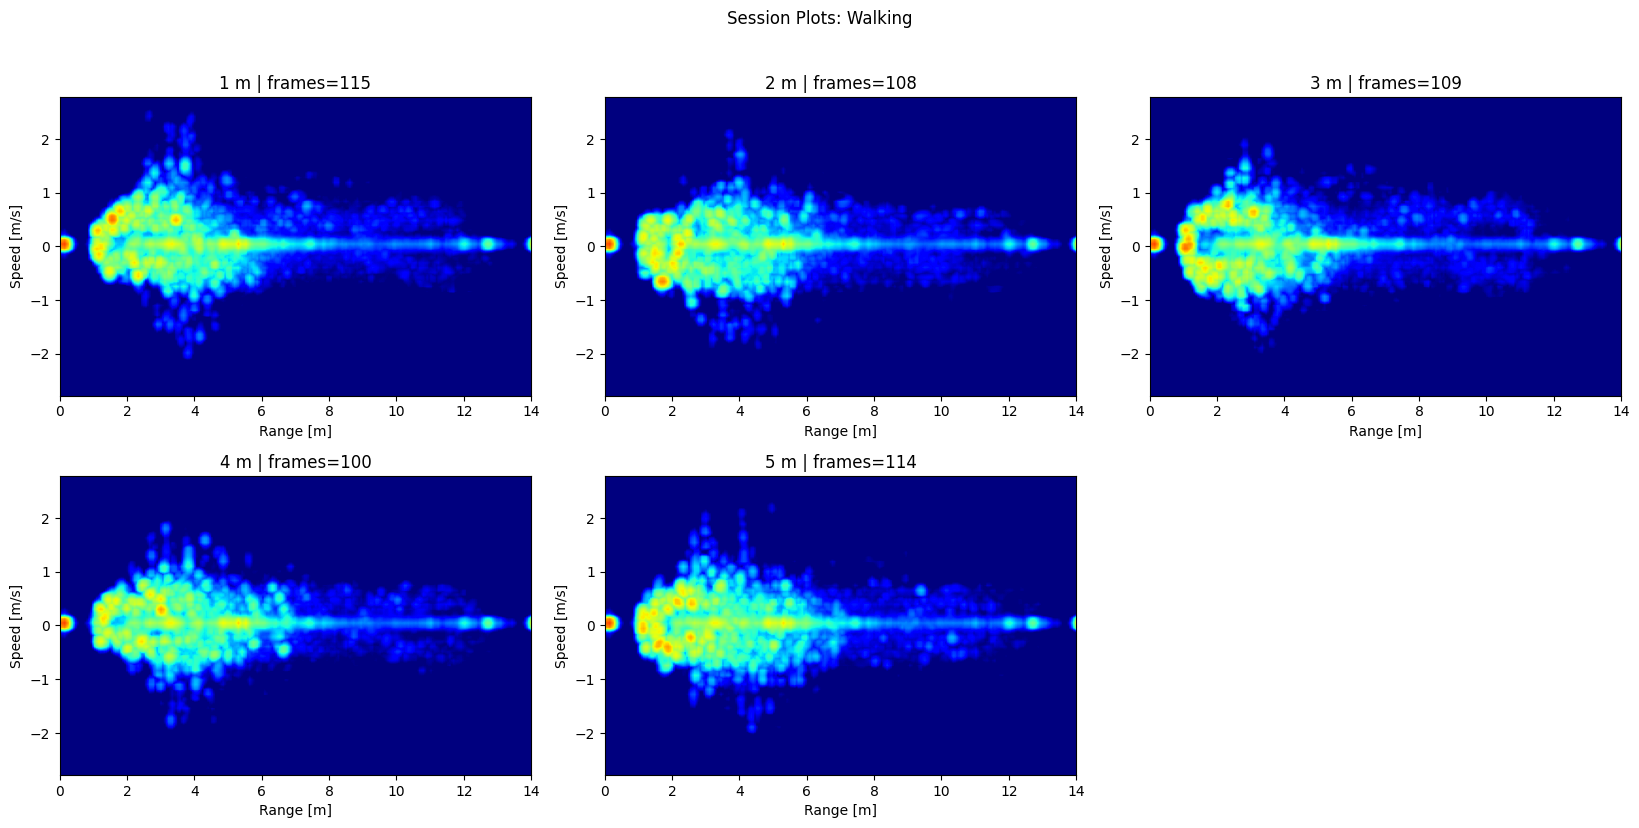

In [5]:
# session plots
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.ndimage import zoom as _zoom
except Exception:
    _zoom = None

if "first_existing_dir" not in globals():
    raise RuntimeError("Run Cell 3 first.")

if "single_root" in globals() and single_root is not None:
    single_root_viz = single_root
elif "single_root_local" in globals() and single_root_local is not None:
    single_root_viz = single_root_local
else:
    raise RuntimeError("Run Cell 3 first.")

single_3d_root_viz = first_existing_dir(single_root_viz, ["3D data", "3D", "3d data", "3d"])
if single_3d_root_viz is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")

SESSION_PLOT_ACTIVITY = None  # "Sitting" for one activity, None for all activities
MAXIMUM_RANGE_M = 14.0
UNAMBIGUOUS_VELOCITY_MPS = 2.78
MIN_VALUE = 2048.0
MAX_VALUE = 4096.0
GRID_SIZE = 250


def _session_sort_key(name: str):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


def _read_rd_csv_any_format(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    needed = ["frame_number", "range_bin", "doppler_bin", "signal_strength"]

    if all(c in df.columns for c in needed):
        out = df[needed].copy()
    else:
        raw = pd.read_csv(csv_path, header=None)
        if raw.shape[1] >= 5:
            raw = raw.iloc[:, :5].copy()
            raw.columns = ["timestamp", "frame_number", "range_bin", "doppler_bin", "signal_strength"]
            out = raw[needed].copy()
        elif raw.shape[1] == 4:
            raw.columns = needed
            out = raw[needed].copy()
        else:
            raise ValueError(f"Unexpected CSV format: {csv_path}")

    out[needed] = out[needed].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=needed)
    out["frame_number"] = out["frame_number"].astype(int)
    out["range_bin"] = out["range_bin"].astype(int)
    out["doppler_bin"] = out["doppler_bin"].astype(int)
    return out


def _build_heatmaps(df: pd.DataFrame):
    heatmaps = []
    frame_numbers = []

    max_range_bin = int(df["range_bin"].max())
    max_doppler_bin = int(df["doppler_bin"].max())
    h = max_range_bin + 1
    w = max_doppler_bin + 1

    for frame_num, part in df.groupby("frame_number", sort=True):
        mat = np.zeros((h, w), dtype=np.float32)
        rb = part["range_bin"].to_numpy(dtype=np.int64)
        db = part["doppler_bin"].to_numpy(dtype=np.int64)
        sig = part["signal_strength"].to_numpy(dtype=np.float32)

        valid = (rb >= 0) & (rb < h) & (db >= 0) & (db < w)
        rb = rb[valid]
        db = db[valid]
        sig = sig[valid]

        if len(sig) > 0:
            mat[rb, db] = sig

        heatmaps.append(mat)
        frame_numbers.append(int(frame_num))

    return heatmaps, frame_numbers


def _filter_anomalous_frames(heatmaps, frame_numbers):
    if len(heatmaps) < 5:
        return heatmaps, frame_numbers

    means = np.array([h.mean() for h in heatmaps], dtype=np.float32)
    stds = np.array([h.std() for h in heatmaps], dtype=np.float32)
    peaks = np.array([h.max() for h in heatmaps], dtype=np.float32)
    sat_counts = np.array([(h > 60000).sum() for h in heatmaps], dtype=np.float32)

    def robust_abs_z(values):
        med = np.median(values)
        mad = np.median(np.abs(values - med))
        if mad < 1e-9:
            return np.zeros_like(values)
        return np.abs((values - med) / (1.4826 * mad))

    z_mean = robust_abs_z(means)
    z_std = robust_abs_z(stds)
    z_peak = robust_abs_z(peaks)

    mask = (
        (sat_counts > 0)
        | (peaks > 10000)
        | (stds > 2000)
        | ((z_peak > 12.0) & (z_std > 12.0) & (z_mean > 12.0))
    )

    kept_heatmaps = [h for i, h in enumerate(heatmaps) if not mask[i]]
    kept_frames = [f for i, f in enumerate(frame_numbers) if not mask[i]]
    return kept_heatmaps, kept_frames


def _resize_2d(arr: np.ndarray, out_h: int, out_w: int) -> np.ndarray:
    if _zoom is not None:
        return _zoom(arr, (out_h / arr.shape[0], out_w / arr.shape[1]), order=1)

    rep_h = int(np.ceil(out_h / arr.shape[0]))
    rep_w = int(np.ceil(out_w / arr.shape[1]))
    up = np.repeat(np.repeat(arr, rep_h, axis=0), rep_w, axis=1)
    return up[:out_h, :out_w]


def _preprocess_frame_for_display(frame: np.ndarray) -> np.ndarray:
    shifted = np.fft.fftshift(frame, axes=1)
    out_h = max(GRID_SIZE, shifted.shape[0])
    out_w = max(GRID_SIZE, shifted.shape[1])
    interp = _resize_2d(shifted, out_h, out_w).astype(np.float32)

    denom = max(MAX_VALUE - MIN_VALUE, 1e-9)
    norm = (interp - MIN_VALUE) / denom
    return np.clip(norm, 0.0, 1.0)


def _build_session_pattern(heatmaps):
    if not heatmaps:
        return np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)

    base_shape = heatmaps[0].shape
    valid_frames = [h for h in heatmaps if h.shape == base_shape]
    if not valid_frames:
        valid_frames = heatmaps

    processed = [_preprocess_frame_for_display(h) for h in valid_frames]
    return np.max(np.stack(processed, axis=0), axis=0)


if SESSION_PLOT_ACTIVITY is None:
    activity_dirs = sorted([d for d in single_3d_root_viz.iterdir() if d.is_dir()])
else:
    activity_dir = single_3d_root_viz / SESSION_PLOT_ACTIVITY
    if not activity_dir.exists():
        available = sorted([d.name for d in single_3d_root_viz.iterdir() if d.is_dir()])
        raise ValueError(f"Activity '{SESSION_PLOT_ACTIVITY}' not found. Available: {available}")
    activity_dirs = [activity_dir]

if not activity_dirs:
    raise ValueError("No activity folders found under Single Activity/3D data")

for activity_dir in activity_dirs:
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir() and (d / "range_doppler.csv").exists()],
        key=lambda p: _session_sort_key(p.name),
    )
    if not session_dirs:
        continue

    plots = []
    for session_dir in session_dirs:
        rd_csv = session_dir / "range_doppler.csv"
        rd_df = _read_rd_csv_any_format(rd_csv)
        heatmaps, frame_numbers = _build_heatmaps(rd_df)
        heatmaps, frame_numbers = _filter_anomalous_frames(heatmaps, frame_numbers)
        if not heatmaps:
            continue

        pattern = _build_session_pattern(heatmaps)
        plots.append((session_dir.name, pattern, len(frame_numbers)))

    if not plots:
        continue

    n = len(plots)
    cols_n = min(3, n)
    rows_n = int(np.ceil(n / cols_n))
    fig, axes = plt.subplots(rows_n, cols_n, figsize=(5.5 * cols_n, 4.2 * rows_n), squeeze=False)

    for idx, (session_name, pattern, frame_count) in enumerate(plots):
        r = idx // cols_n
        c = idx % cols_n
        ax = axes[r][c]
        ax.imshow(
            pattern.T,
            origin="lower",
            aspect="auto",
            cmap="jet",
            vmin=0.0,
            vmax=1.0,
            extent=[0.0, MAXIMUM_RANGE_M, -UNAMBIGUOUS_VELOCITY_MPS, UNAMBIGUOUS_VELOCITY_MPS],
        )
        ax.set_title(f"{session_name} | frames={frame_count}")
        ax.set_xlabel("Range [m]")
        ax.set_ylabel("Speed [m/s]")

    for idx in range(n, rows_n * cols_n):
        r = idx // cols_n
        c = idx % cols_n
        axes[r][c].axis("off")

    fig.suptitle(f"Session Plots: {activity_dir.name}")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [6]:
import re
import pandas as pd

# Build two session-wise collections, then concatenate into one DF each.
if "single_root" not in globals() or single_root is None:
    raise RuntimeError("Run Cell 3 first.")
if "first_existing_dir" not in globals() or "first_existing_file" not in globals():
    raise RuntimeError("Run Cell 3 first.")

single_3d_root_load = first_existing_dir(single_root, ["3D data", "3D", "3d data", "3d"])
if single_3d_root_load is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")


def _session_sort_key(name: str):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


pointcloud_snr_by_session = {}
range_doppler_by_session = {}

for activity_dir in sorted([d for d in single_3d_root_load.iterdir() if d.is_dir()]):
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir()],
        key=lambda p: _session_sort_key(p.name),
    )

    for session_dir in session_dirs:
        session_key = (activity_dir.name, session_dir.name)

        pc_path = first_existing_file(
            session_dir,
            ["PointCloud_snr.csv", "point_cloud_snr.csv", "points_cloud_snr.csv"],
        )
        rd_path = session_dir / "range_doppler.csv"

        if pc_path is not None:
            pc_df = pd.read_csv(pc_path)
            pc_df.insert(0, "sample", session_dir.name)
            pc_df.insert(0, "activity", activity_dir.name)
            pointcloud_snr_by_session[session_key] = pc_df

        if rd_path.exists():
            rd_df = pd.read_csv(rd_path)
            rd_df.insert(0, "sample", session_dir.name)
            rd_df.insert(0, "activity", activity_dir.name)
            range_doppler_by_session[session_key] = rd_df

pointcloud_snr_df = (
    pd.concat(pointcloud_snr_by_session.values(), ignore_index=True)
    if pointcloud_snr_by_session
    else pd.DataFrame()
)

range_doppler_df = (
    pd.concat(range_doppler_by_session.values(), ignore_index=True)
    if range_doppler_by_session
    else pd.DataFrame()
)

print(f"PointCloud sessions loaded: {len(pointcloud_snr_by_session)}")
print(f"Range-Doppler sessions loaded: {len(range_doppler_by_session)}")
print(f"pointcloud_snr_df shape: {pointcloud_snr_df.shape}")
print(f"range_doppler_df shape: {range_doppler_df.shape}")

display(pointcloud_snr_df.head())
display(range_doppler_df.head())

PointCloud sessions loaded: 20
Range-Doppler sessions loaded: 20
pointcloud_snr_df shape: (5954, 13)
range_doppler_df shape: (20193280, 7)


,activity,sample,timestamp_s,frame_number,point_index,x,y,z,doppler,range,aoa,snr,noise
0,Sitting,1 m,0.000000,1,0,-0.115626,0.041640,-0.025776,0.000000,0.125570,160.194763,21.8,66.8
1,Sitting,1 m,0.000000,1,1,0.138751,1.499150,0.062017,0.000000,1.506834,84.712144,17.6,65.3
2,Sitting,1 m,0.000000,1,2,-0.647507,1.547589,-0.525522,-1.023127,1.757974,112.704297,19.8,41.6
3,Sitting,1 m,0.000000,1,3,0.000000,1.259066,1.226875,-1.023127,1.757974,90.000000,19.8,41.6
4,Sitting,1 m,0.297168,2,0,-0.115626,0.041632,-0.025789,0.000000,0.125570,160.198342,18.9,69.7


,activity,sample,timestamp_s,frame_number,range_bin,doppler_bin,signal_strength
0,Sitting,1 m,0.0,1,0,0,3704
1,Sitting,1 m,0.0,1,0,1,3519
2,Sitting,1 m,0.0,1,0,2,2272
3,Sitting,1 m,0.0,1,0,3,2000
4,Sitting,1 m,0.0,1,0,4,1843


In [7]:
print("Point Cloud Missing Values:")
print(pointcloud_snr_df.isnull().sum())

print("Range-Doppler Missing Values:")
print(range_doppler_df.isnull().sum())

Point Cloud Missing Values:
activity        0
sample          0
timestamp_s     0
frame_number    0
point_index     0
x               0
y               0
z               0
doppler         0
range           0
aoa             0
snr             0
noise           0
dtype: int64
Range-Doppler Missing Values:
activity           0
sample             0
timestamp_s        0
frame_number       0
range_bin          0
doppler_bin        0
signal_strength    0
dtype: int64


why median not mean
- Median used instead of mean because the point cloud data contains significant noise, and outliers, and median provides a more robust estimate of true target

- Mean calcuate all the values which enforce deviation of actual value and treads to go outliers values

-(ask prof if I need to show this from data)

In [8]:
import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.3f}".format)

range_stats = (
    pointcloud_snr_df
    .groupby(["activity", "sample"])["range"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        count="count"
    )
    .reset_index()
)

print("=== Range Statistics ===")
display(range_stats)

=== Range Statistics ===


,activity,sample,mean,median,std,min,max,count
0,Sitting,1 m,1.672,1.507,1.717,0.126,6.278,401
1,Sitting,2 m,1.410,1.884,1.245,0.126,7.911,292
2,Sitting,3 m,0.788,0.126,1.470,0.126,4.646,151
3,Sitting,4 m,0.584,0.126,1.397,0.126,5.651,152
4,Sitting,5 m,0.768,0.126,1.777,0.126,6.153,159
5,Standing,1 m,0.909,1.256,0.773,0.126,2.763,301
6,Standing,2 m,1.611,2.386,1.371,0.126,3.767,316
7,Standing,3 m,1.242,0.126,1.731,0.126,4.521,201
8,Standing,4 m,1.435,0.126,2.311,0.126,6.906,181
9,Standing,5 m,1.023,0.126,2.024,0.126,6.530,193


Insights: 

- std high means noice high (0.3-0.5 normal)
- median =~ actual distance (short distance)
- low counts means weak detection 

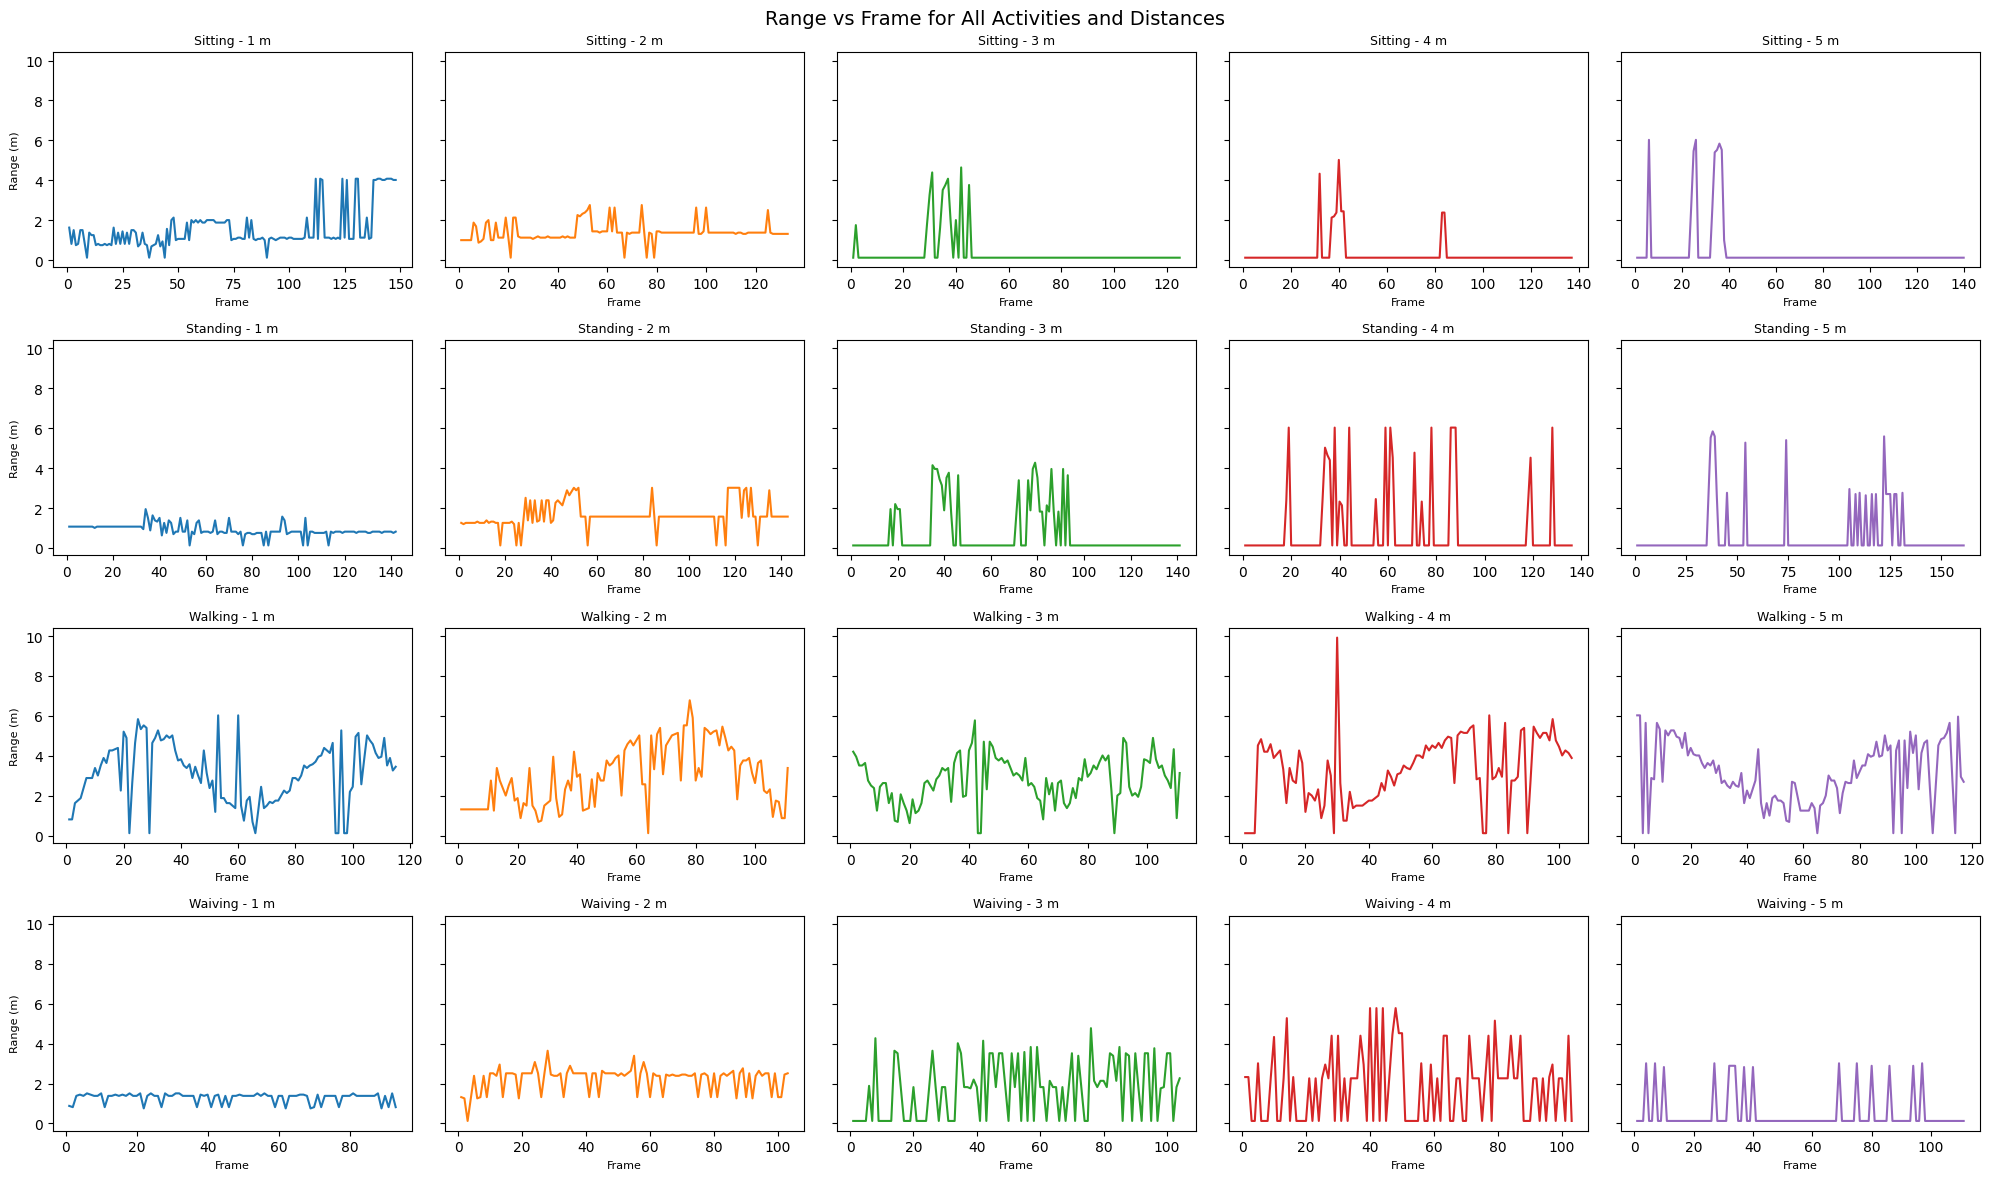

In [9]:
# Range vs Frame plots

import matplotlib.pyplot as plt

activities = ["Sitting", "Standing", "Walking", "Waiving"]
distances = ["1 m", "2 m", "3 m", "4 m", "5 m"]
distance_colors = {
    "1 m": "#1f77b4",
    "2 m": "#ff7f0e",
    "3 m": "#2ca02c",
    "4 m": "#d62728",
    "5 m": "#9467bd",
}

fig, axes = plt.subplots(len(activities), len(distances), figsize=(20, 12), sharex=False, sharey=True)

for i, act in enumerate(activities):
    for j, dist in enumerate(distances):
        
        df = pointcloud_snr_df[
            (pointcloud_snr_df["activity"] == act) &
            (pointcloud_snr_df["sample"] == dist)
        ]
        
        if not df.empty:
            feature_per_frame = df.groupby("frame_number")["range"].median()
            axes[i, j].plot(
                feature_per_frame.index,
                feature_per_frame.values,
                color=distance_colors.get(dist, "#333333"),
            )
        
        axes[i, j].set_title(f"{act} - {dist}", fontsize=9)
        axes[i, j].set_xlabel("Frame", fontsize=8)
        
        if j == 0:
            axes[i, j].set_ylabel("Range (m)", fontsize=8)

plt.suptitle("Range vs Frame for All Activities and Distances", fontsize=14)
plt.tight_layout()
plt.show()

### Observations:
- At **short distances (1 m and 2 m)**, the range values remain relatively stable and cluster around the true target distance, indicating reliable detection.
- As the distance increases (**3 m and beyond**), the range measurements become sparse and inconsistent, with only occasional spikes.
- At **4 m and 5 m**, the radar fails to consistently detect the target, and the plot is dominated by isolated peaks and noise.
- Among activities, **walking** shows smoother and continuous variation in range, while **sitting and standing** exhibit more static behavior with occasional spikes.
- **Waving** produces small fluctuations but lacks large-scale range variation due to limited body movement.

### Insights:
- Radar detection quality **degrades significantly with distance**, leading to unstable range estimation.
- Static or low-motion activities (sitting, standing) are more difficult to capture reliably, especially at longer distances.
- Dynamic activities (walking) provide stronger and more consistent range signatures.
- The presence of spikes confirms **noise and multipath reflections**, justifying the use of median instead of mean for aggregation.

In [10]:
doppler_stats = (
    pointcloud_snr_df
    .groupby(["activity", "sample"])["doppler"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        count="count"
    )
    .reset_index()
)

print("=== Doppler Statistics ===")
display(doppler_stats)

=== Doppler Statistics ===


,activity,sample,mean,median,std,min,max,count
0,Sitting,1 m,0.008,0.000,0.180,-1.023,1.194,401
1,Sitting,2 m,0.027,0.000,0.118,-0.426,0.682,292
2,Sitting,3 m,0.027,0.000,0.145,-0.512,0.512,151
3,Sitting,4 m,0.017,0.000,0.123,-0.597,0.597,152
4,Sitting,5 m,0.023,0.000,0.098,-0.256,0.512,159
5,Standing,1 m,-0.022,0.000,0.166,-1.876,0.426,301
6,Standing,2 m,0.013,0.000,0.108,-0.426,0.597,316
7,Standing,3 m,-0.026,0.000,0.206,-0.938,0.512,201
8,Standing,4 m,-0.001,0.000,0.127,-0.426,0.682,181
9,Standing,5 m,-0.019,0.000,0.141,-0.512,0.597,193


Insights:
- mean ~= 0, static activity
- High std, motion high
- max/min, peak valocity (highest val comimg towards or away from radar)

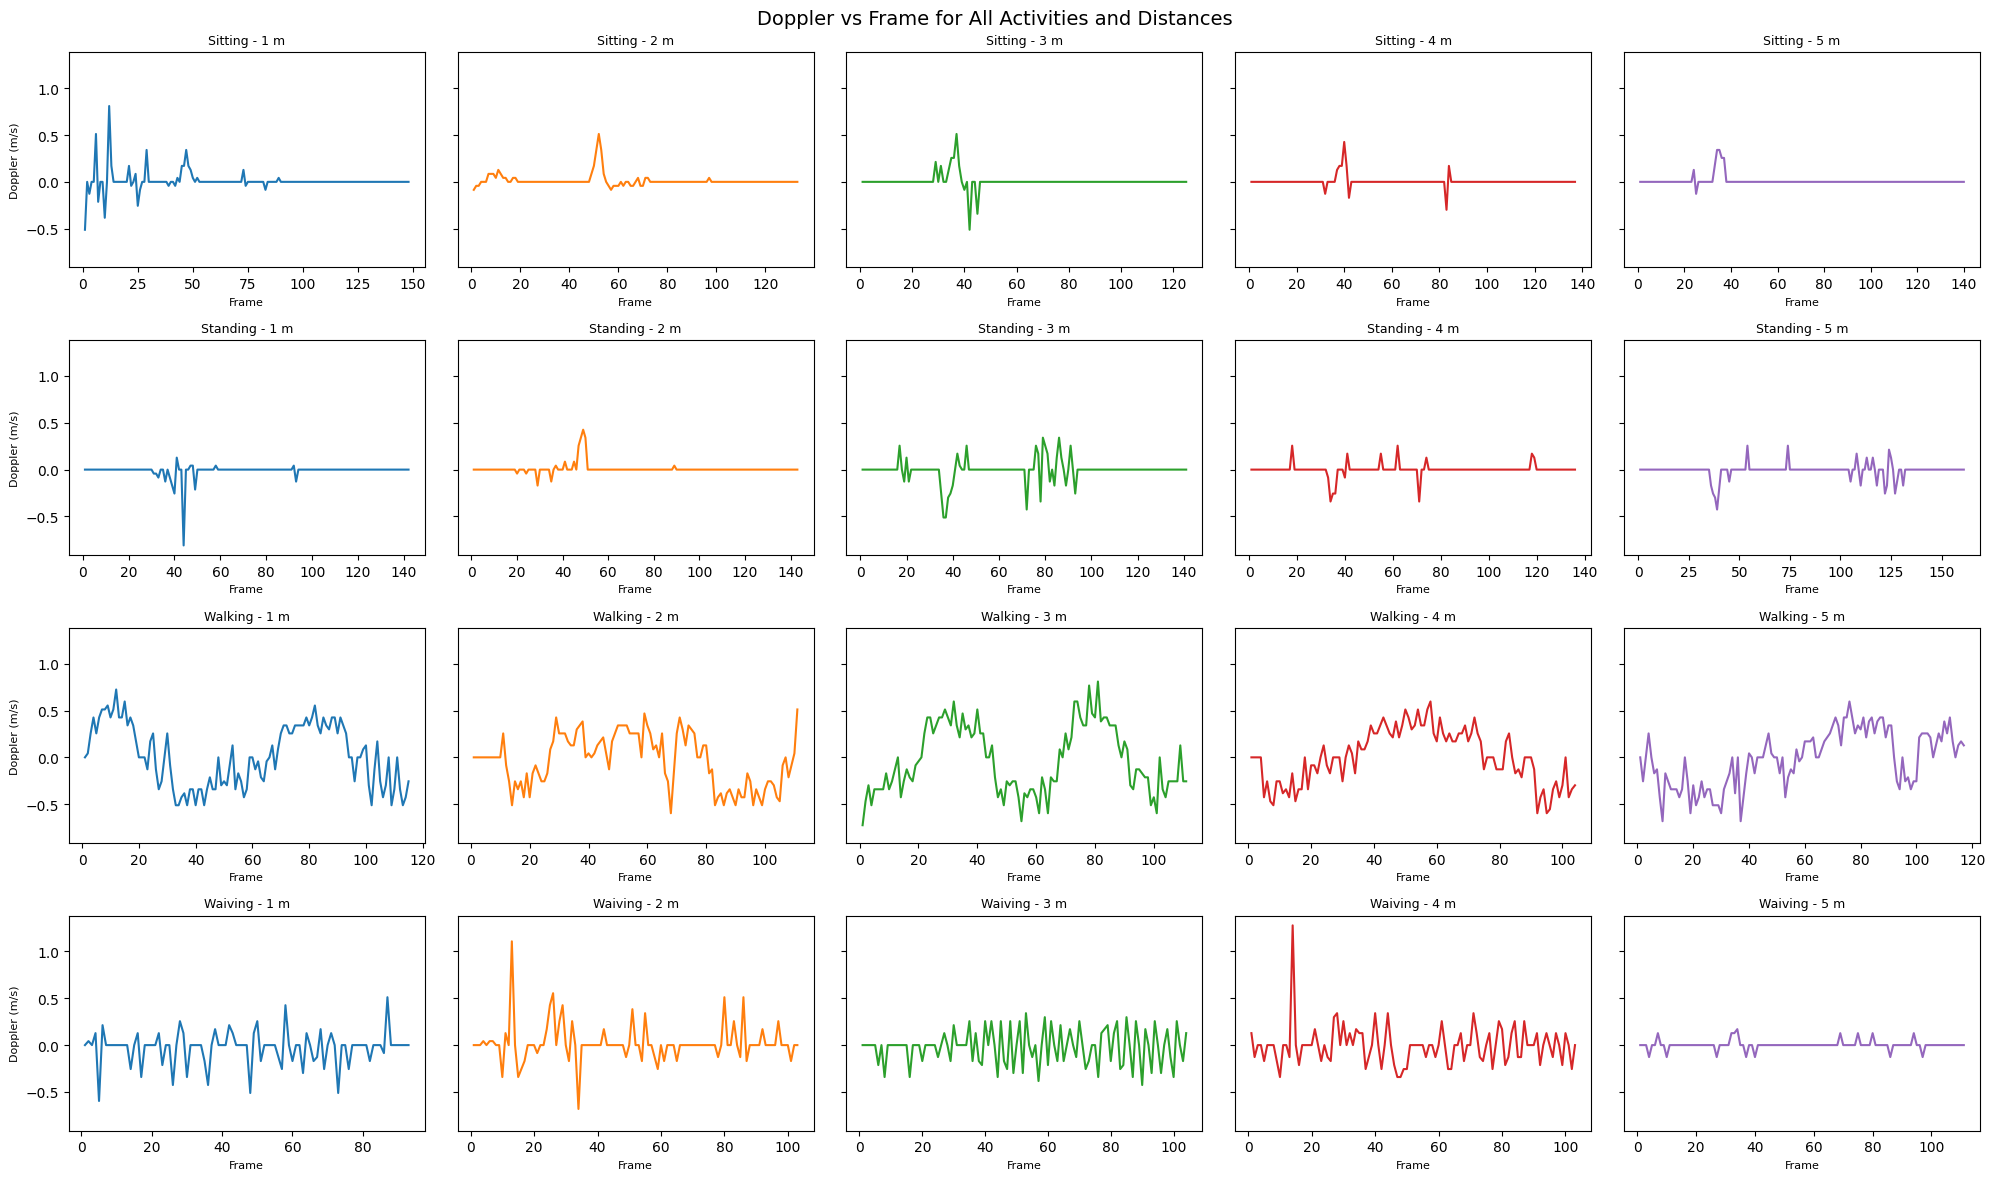

In [11]:
# Doppler vs Frame plots (same layout as Range vs Frame)

import matplotlib.pyplot as plt

activities = ["Sitting", "Standing", "Walking", "Waiving"]
distances = ["1 m", "2 m", "3 m", "4 m", "5 m"]
distance_colors = {
    "1 m": "#1f77b4",
    "2 m": "#ff7f0e",
    "3 m": "#2ca02c",
    "4 m": "#d62728",
    "5 m": "#9467bd",
}

fig, axes = plt.subplots(len(activities), len(distances), figsize=(20, 12), sharex=False, sharey=True)

for i, act in enumerate(activities):
    for j, dist in enumerate(distances):
        df = pointcloud_snr_df[
            (pointcloud_snr_df["activity"] == act) &
            (pointcloud_snr_df["sample"] == dist)
        ]

        if not df.empty:
            doppler_per_frame = (
                df.groupby("frame_number")["doppler"]
                .median()
                .sort_index()
            )
            axes[i, j].plot(
                doppler_per_frame.index,
                doppler_per_frame.values,
                color=distance_colors.get(dist, "#333333"),
            )

        axes[i, j].set_title(f"{act} - {dist}", fontsize=9)
        axes[i, j].set_xlabel("Frame", fontsize=8)

        if j == 0:
            axes[i, j].set_ylabel("Doppler (m/s)", fontsize=8)

plt.suptitle("Doppler vs Frame for All Activities and Distances", fontsize=14)
plt.tight_layout()
plt.show()


### Observations:
- For **sitting and standing**, Doppler values remain close to zero for most frames, with brief spikes during transitions (e.g., sit-to-stand or stand-to-sit).
- **Walking** exhibits continuous Doppler variation, indicating sustained motion throughout the session.
- **Waving** shows oscillatory Doppler patterns, reflecting repetitive hand movement.
- At larger distances, Doppler signals become weaker and less consistent, especially for low-motion activities.

### Insights:
- Doppler is highly effective in distinguishing **static vs dynamic activities**.
- **Walking** can be clearly identified due to its continuous motion signature.
- **Waving** produces a distinct oscillatory pattern, making it separable from static activities.
- **Sitting and standing** are difficult to distinguish based solely on Doppler, except during transition phases.
- Doppler features are more robust than range for capturing **motion-based activity patterns**, especially at moderate distances.

In [12]:
points_per_frame = (
    pointcloud_snr_df
    .groupby(["activity", "sample", "frame_number"])
    .size()
    .reset_index(name="points")
)

points_stats = (
    points_per_frame
    .groupby(["activity", "sample"])["points"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        count="count"
    )
    .reset_index()
)

print("=== Points Statistics ===")
display(points_stats)

=== Points Statistics ===


,activity,sample,mean,median,std,min,max,count
0,Sitting,1 m,2.709,2.000,1.108,1,8,148
1,Sitting,2 m,2.195,2.000,0.657,1,6,133
2,Sitting,3 m,1.208,1.000,0.786,1,7,125
3,Sitting,4 m,1.109,1.000,0.538,1,6,137
4,Sitting,5 m,1.136,1.000,0.526,1,4,140
5,Standing,1 m,2.120,2.000,0.539,1,4,142
6,Standing,2 m,2.210,2.000,0.680,1,5,143
7,Standing,3 m,1.426,1.000,0.973,1,6,141
8,Standing,4 m,1.331,1.000,0.835,1,6,136
9,Standing,5 m,1.199,1.000,0.611,1,5,161


Insights:
- mean points goes down with distance
- std high, unstable detection

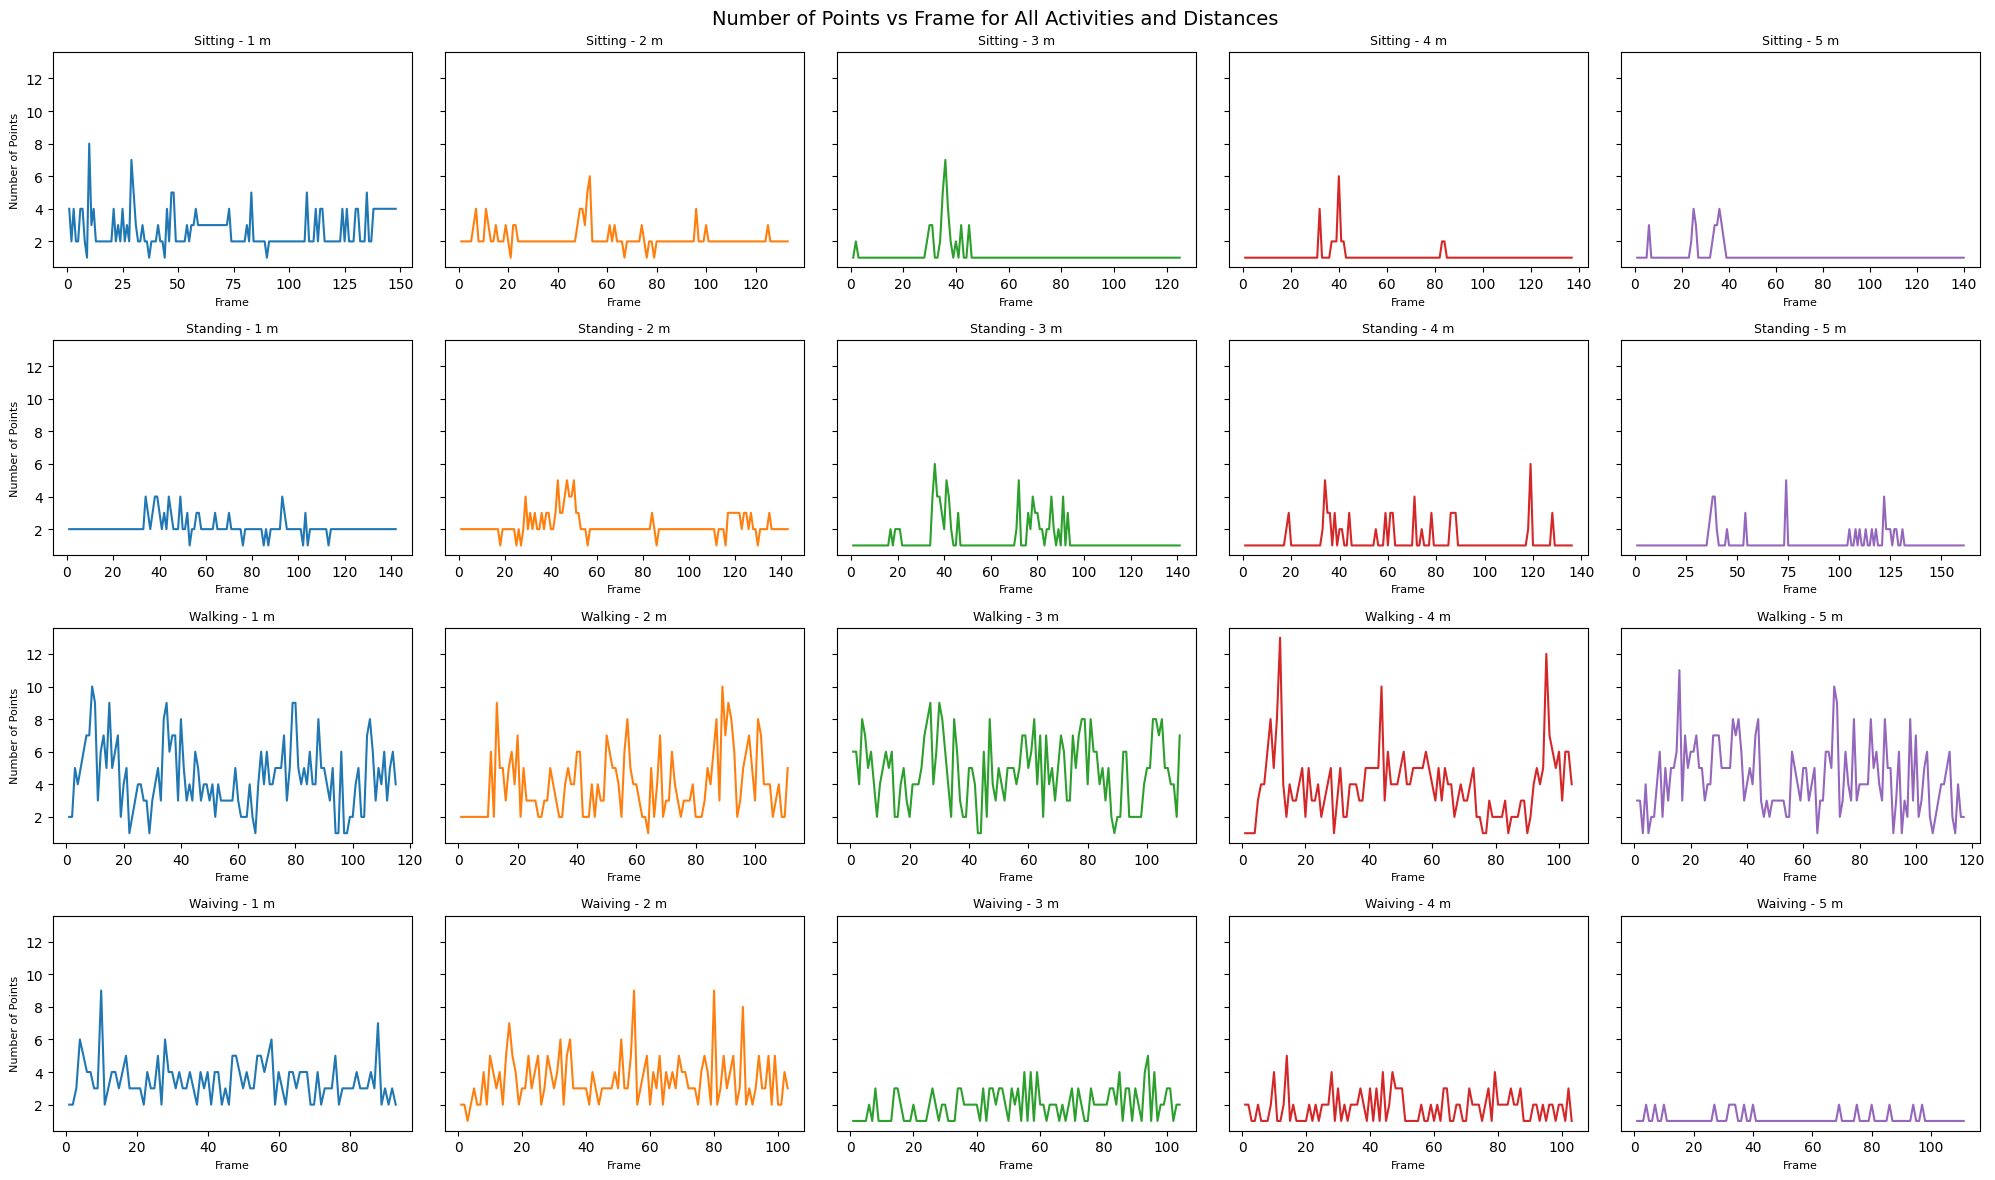

In [13]:
# Number of Points vs Frame plots (same layout as Range vs Frame)

import matplotlib.pyplot as plt

activities = ["Sitting", "Standing", "Walking", "Waiving"]
distances = ["1 m", "2 m", "3 m", "4 m", "5 m"]
distance_colors = {
    "1 m": "#1f77b4",
    "2 m": "#ff7f0e",
    "3 m": "#2ca02c",
    "4 m": "#d62728",
    "5 m": "#9467bd",
}

fig, axes = plt.subplots(len(activities), len(distances), figsize=(20, 12), sharex=False, sharey=True)

for i, act in enumerate(activities):
    for j, dist in enumerate(distances):
        df = pointcloud_snr_df[
            (pointcloud_snr_df["activity"] == act) &
            (pointcloud_snr_df["sample"] == dist)
        ]

        if not df.empty:
            points_per_frame = (
                df.groupby("frame_number")
                .size()
                .sort_index()
            )
            axes[i, j].plot(
                points_per_frame.index,
                points_per_frame.values,
                color=distance_colors.get(dist, "#333333"),
            )

        axes[i, j].set_title(f"{act} - {dist}", fontsize=9)
        axes[i, j].set_xlabel("Frame", fontsize=8)

        if j == 0:
            axes[i, j].set_ylabel("Number of Points", fontsize=8)

plt.suptitle("Number of Points vs Frame for All Activities and Distances", fontsize=14)
plt.tight_layout()
plt.show()

### Observations:
- At **short distances (1 m and 2 m)**, the number of detected points is relatively high and consistent across frames.
- As the distance increases, the number of points per frame **decreases significantly**.
- At **4 m and 5 m**, many frames contain very few or no detected points.
- **Walking** generally produces a higher number of points compared to sitting and standing, due to continuous body movement.
- **Waving** produces moderate point counts, higher than static activities but lower than walking.

### Insights:
- Point cloud density is strongly dependent on **distance**, with rapid degradation at longer ranges.
- Low point density at far distances leads to unreliable feature extraction and increased noise.
- Dynamic activities generate more detectable reflections, improving point cloud quality.
- Static activities suffer from sparse detections, making them harder to analyze using point cloud data alone.

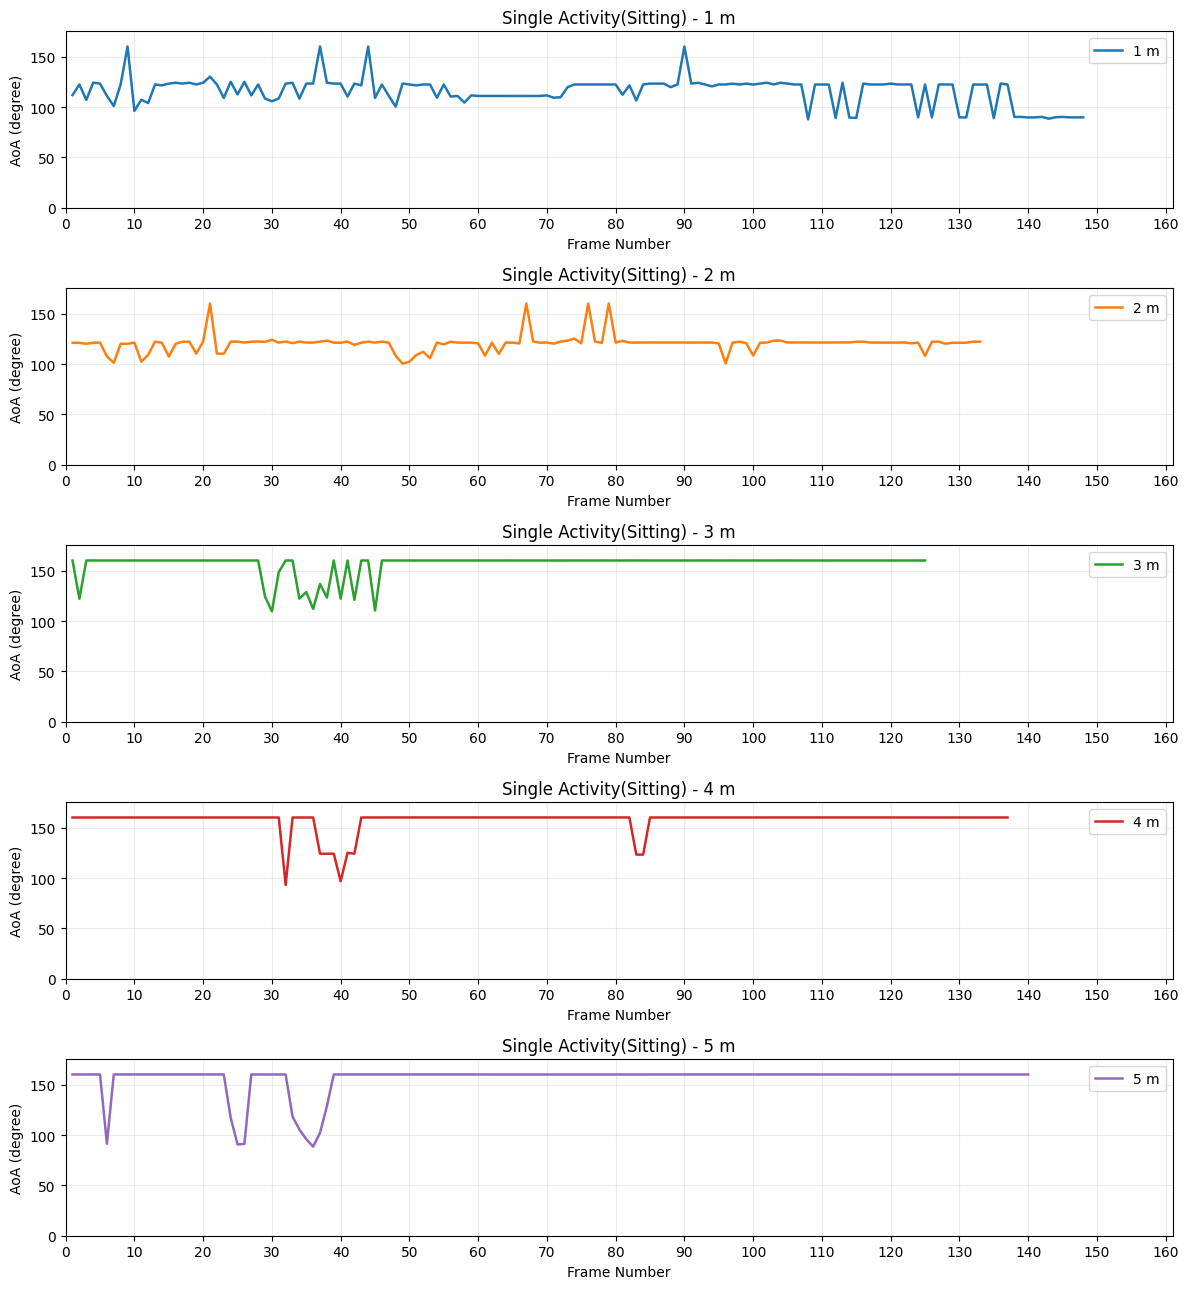

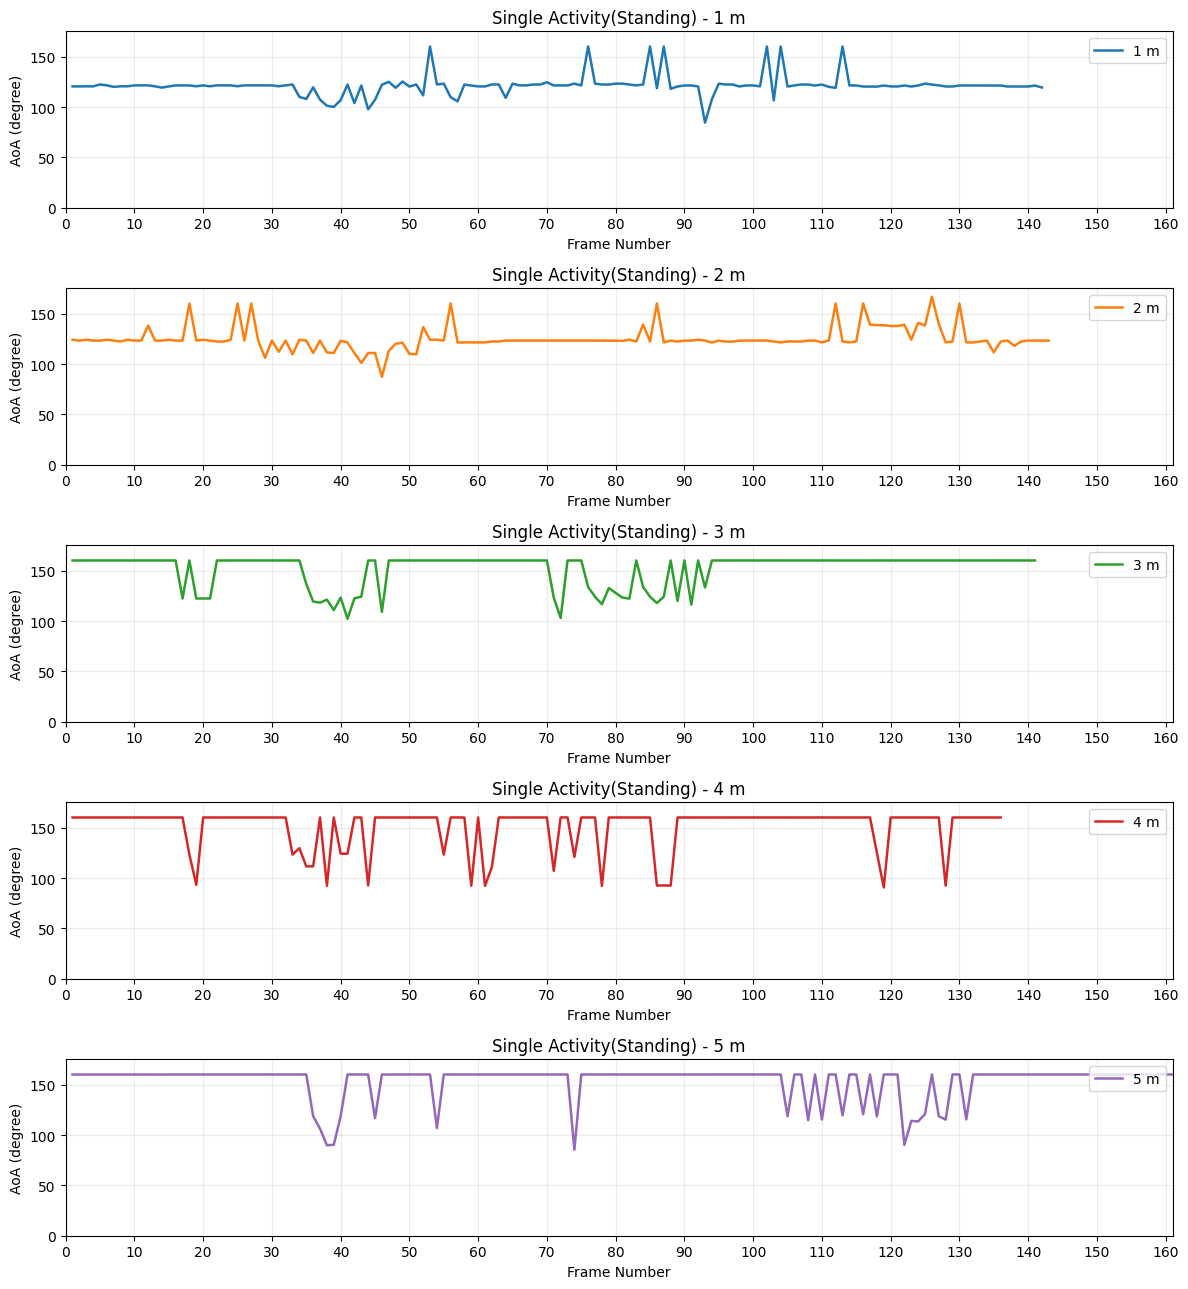

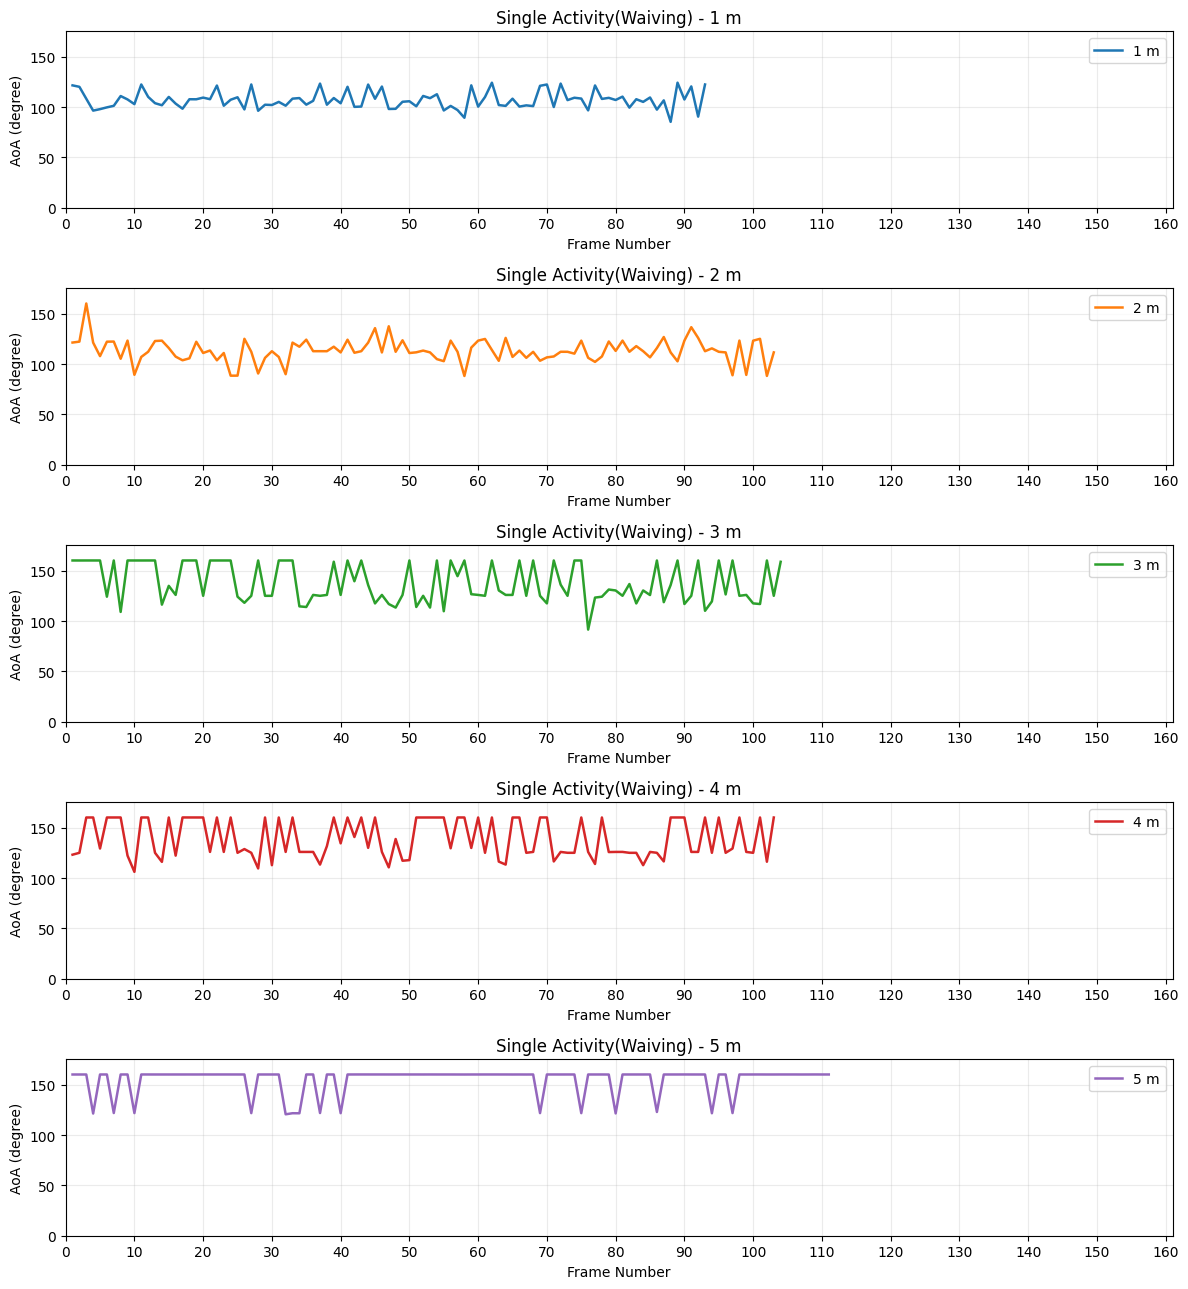

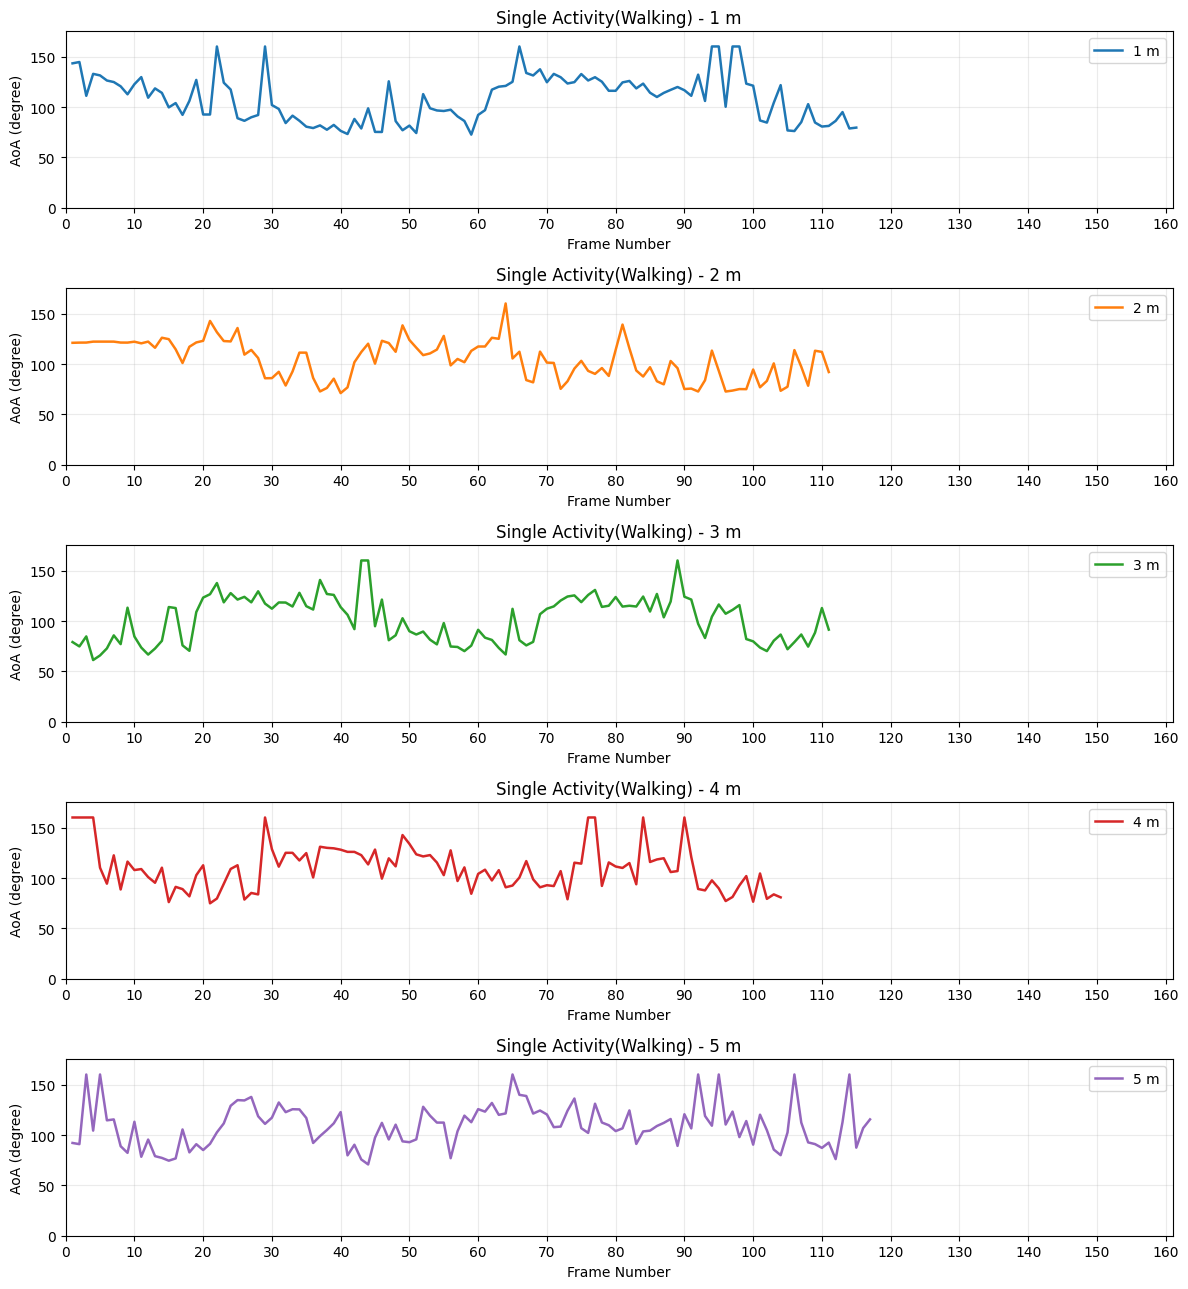

In [14]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator


# Reuse objects from Cell 3.
if "single_root" not in globals() or single_root is None:
    raise RuntimeError("Run Cell 3 first.")
if "first_existing_dir" not in globals() or "first_existing_file" not in globals():
    raise RuntimeError("Run Cell 3 first.")

single_3d_root = first_existing_dir(single_root, ["3D data"])
if single_3d_root is None:
    raise FileNotFoundError("Single Activity 3D folder not found.")


def aoa_per_frame(csv_path):
    df = pd.read_csv(csv_path)
    cols = {str(c).strip().lower(): c for c in df.columns}
    if "frame_number" not in cols or "aoa" not in cols:
        return pd.DataFrame(columns=["frame_number", "aoa"])

    out = df[[cols["frame_number"], cols["aoa"]]].copy()
    out.columns = ["frame_number", "aoa"]
    out["frame_number"] = pd.to_numeric(out["frame_number"], errors="coerce")
    out["aoa"] = pd.to_numeric(out["aoa"], errors="coerce")
    out = out.dropna(subset=["frame_number", "aoa"])
    if out.empty:
        return out

    out["frame_number"] = out["frame_number"].astype(int)
    return out.groupby("frame_number", as_index=False)["aoa"].mean().sort_values("frame_number")


def session_sort_key(name):
    m = re.search(r"\d+(?:\.\d+)?", str(name))
    return float(m.group(0)) if m else float("inf")


# Build curves first so all plots can use the same axis origin/range.
activity_curves = {}
all_frame_max = 0
all_aoa_max = 0.0
distance_colors = {
    "1 m": "#1f77b4",
    "2 m": "#ff7f0e",
    "2.5 m": "#17becf",
    "3 m": "#2ca02c",
    "4 m": "#d62728",
    "5 m": "#9467bd",
}

for activity_dir in sorted([d for d in single_3d_root.iterdir() if d.is_dir()]):
    session_dirs = sorted(
        [d for d in activity_dir.iterdir() if d.is_dir()],
        key=lambda p: session_sort_key(p.name),
    )

    session_curves = []
    for session_dir in session_dirs:
        csv_path = first_existing_file(session_dir, ["PointCloud_snr.csv"])
        if csv_path is None:
            continue

        curve = aoa_per_frame(csv_path)
        if curve.empty:
            continue

        m = re.search(r"\d+(?:\.\d+)?", session_dir.name)
        dist_label = f"{m.group(0)} m" if m else session_dir.name
        color = distance_colors.get(dist_label, "#333333")
        session_curves.append((session_dir.name, curve, color))

        all_frame_max = max(all_frame_max, int(curve["frame_number"].max()))
        all_aoa_max = max(all_aoa_max, float(curve["aoa"].max()))

    if session_curves:
        activity_curves[activity_dir.name] = session_curves

if not activity_curves:
    raise ValueError("No valid AoA data found to plot.")

# Same origin and range for all plots.
x_min, x_max = 0, all_frame_max
y_min, y_max = 0.0, all_aoa_max * 1.05

for activity_name, session_curves in activity_curves.items():
     # Distance-wise plots for this activity in one figure.
    n = len(session_curves)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6 * n), sharex=True, sharey=True)
    if n == 1:
        axes = [axes]

    for ax, (session_name, curve, color) in zip(axes, session_curves):
        ax.plot(curve["frame_number"], curve["aoa"], color=color, linewidth=1.8)
        ax.set_title(f"Single Activity({activity_name}) - {session_name}")
        ax.set_ylabel("AoA (degree)")
        ax.set_xlabel("Frame Number")
        ax.grid(alpha=0.25)
        ax.legend([session_name], loc="upper right")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.tick_params(axis="x", labelbottom=True)

    plt.tight_layout()
    plt.show()

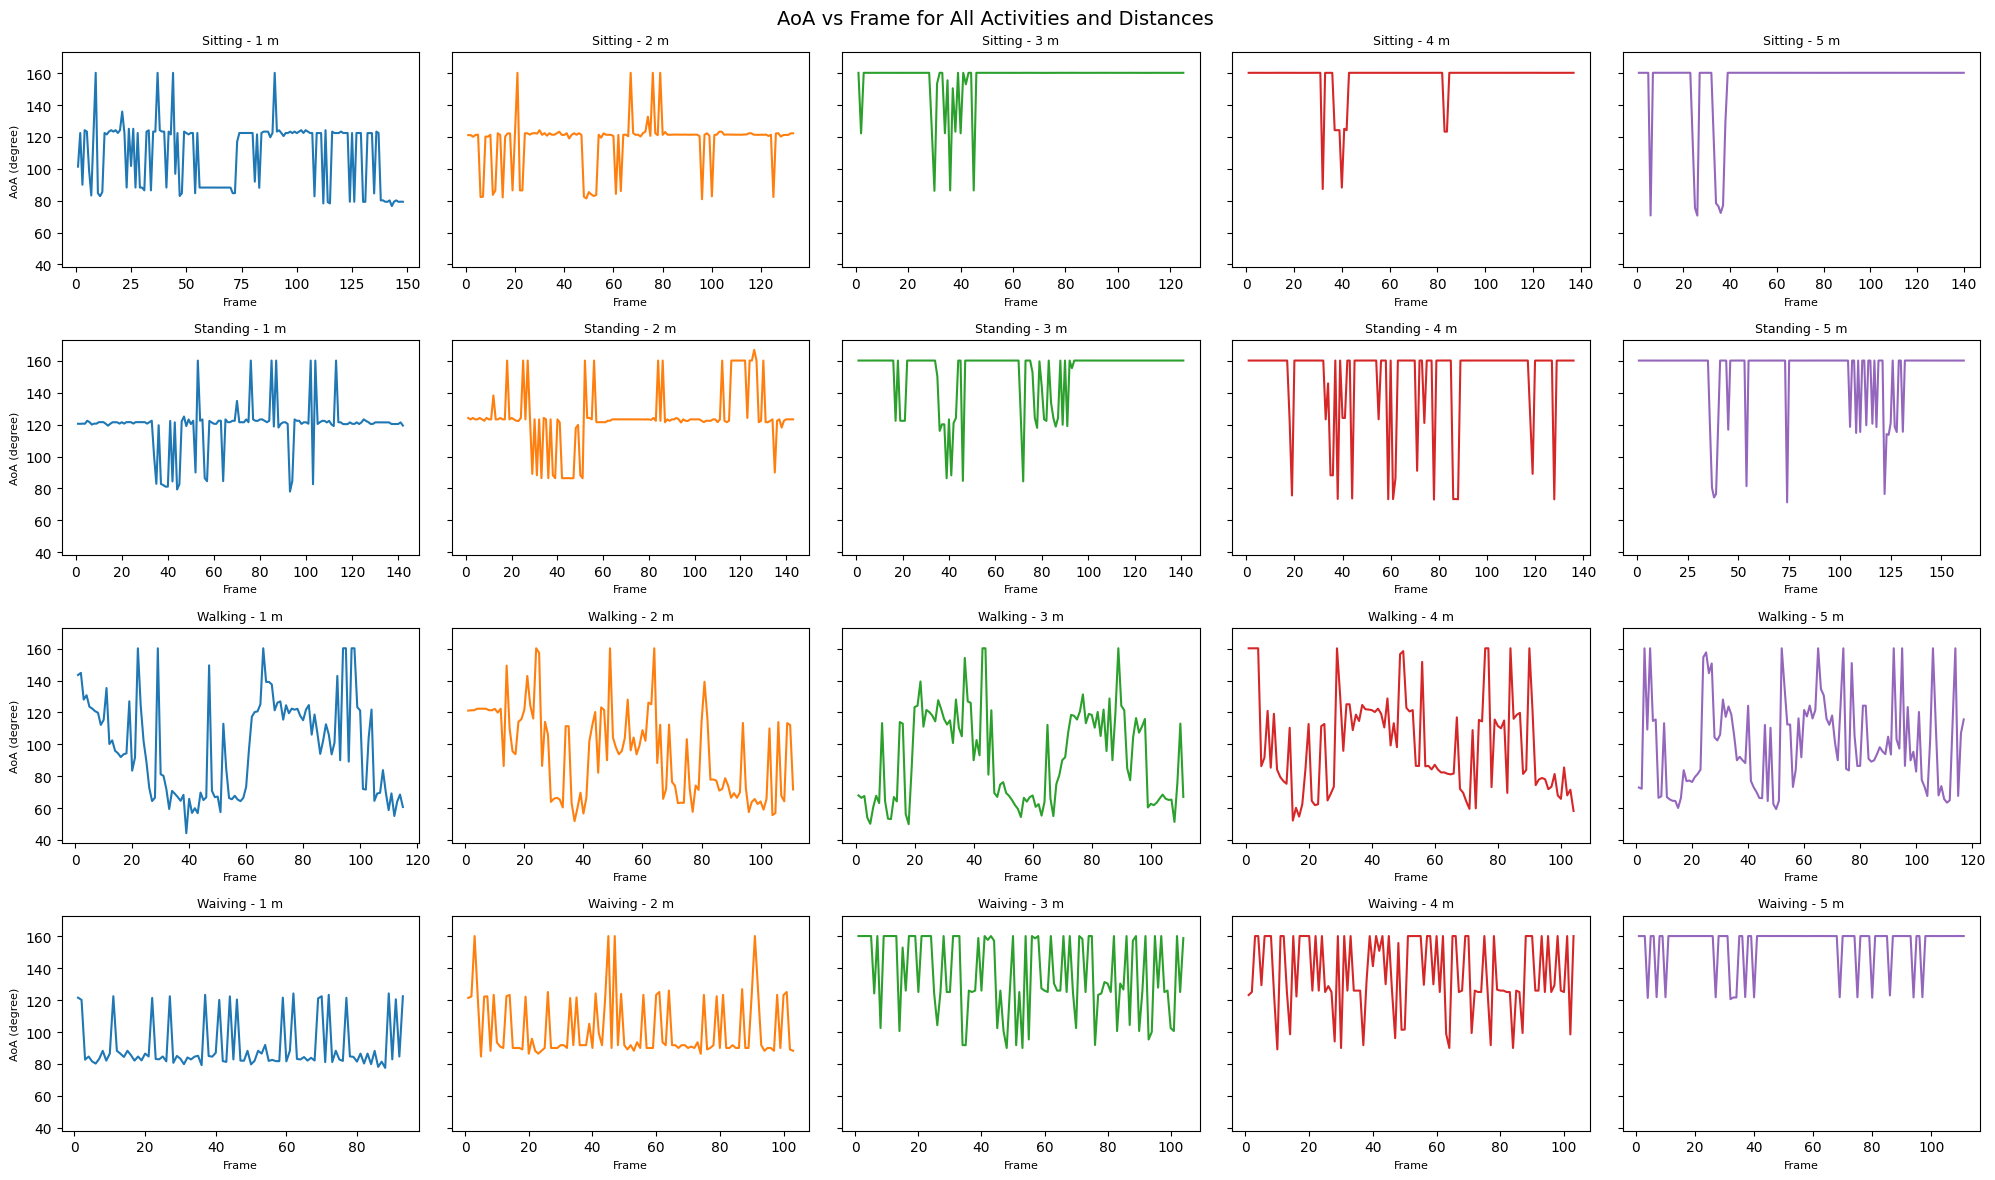

In [15]:
# AoA vs Frame plots
activities = ["Sitting", "Standing", "Walking", "Waiving"]
distances = ["1 m", "2 m", "3 m", "4 m", "5 m"]
distance_colors = {
    "1 m": "#1f77b4",
    "2 m": "#ff7f0e",
    "3 m": "#2ca02c",
    "4 m": "#d62728",
    "5 m": "#9467bd",
}

fig, axes = plt.subplots(len(activities), len(distances), figsize=(20, 12), sharex=False, sharey=True)

for i, act in enumerate(activities):
    for j, dist in enumerate(distances):
        
        df = pointcloud_snr_df[
            (pointcloud_snr_df["activity"] == act) &
            (pointcloud_snr_df["sample"] == dist)
        ]

        if not df.empty:
            # Compute AoA per frame
            aoa_per_frame = (
                df.groupby("frame_number")["aoa"]
                .median()   # you can change to mean() if needed
                .sort_index()
            )

            axes[i, j].plot(
                aoa_per_frame.index,
                aoa_per_frame.values,
                color=distance_colors.get(dist, "#333333"),
            )

        axes[i, j].set_title(f"{act} - {dist}", fontsize=9)
        axes[i, j].set_xlabel("Frame", fontsize=8)

        if j == 0:
            axes[i, j].set_ylabel("AoA (degree)", fontsize=8)

plt.suptitle("AoA vs Frame for All Activities and Distances", fontsize=14)
plt.tight_layout()
plt.show()

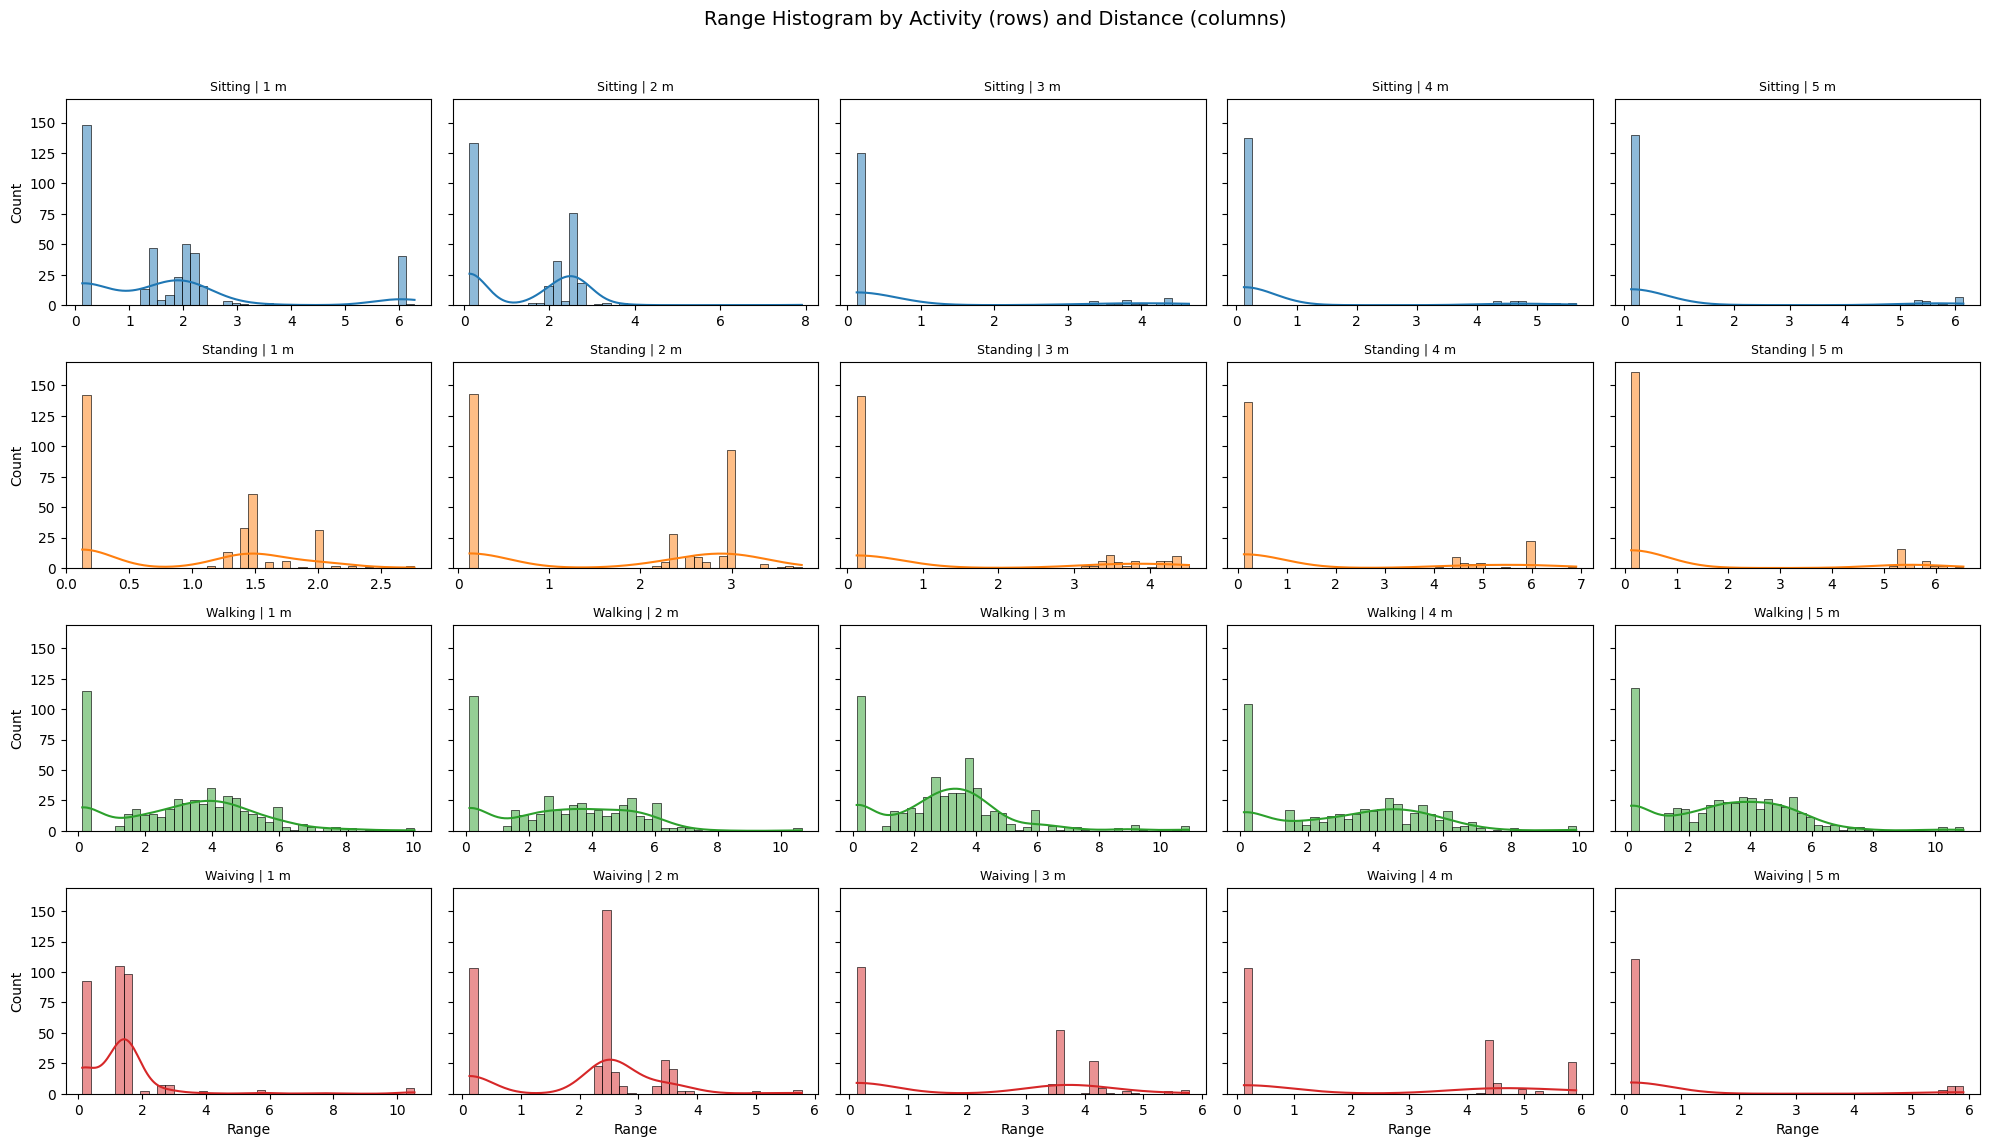

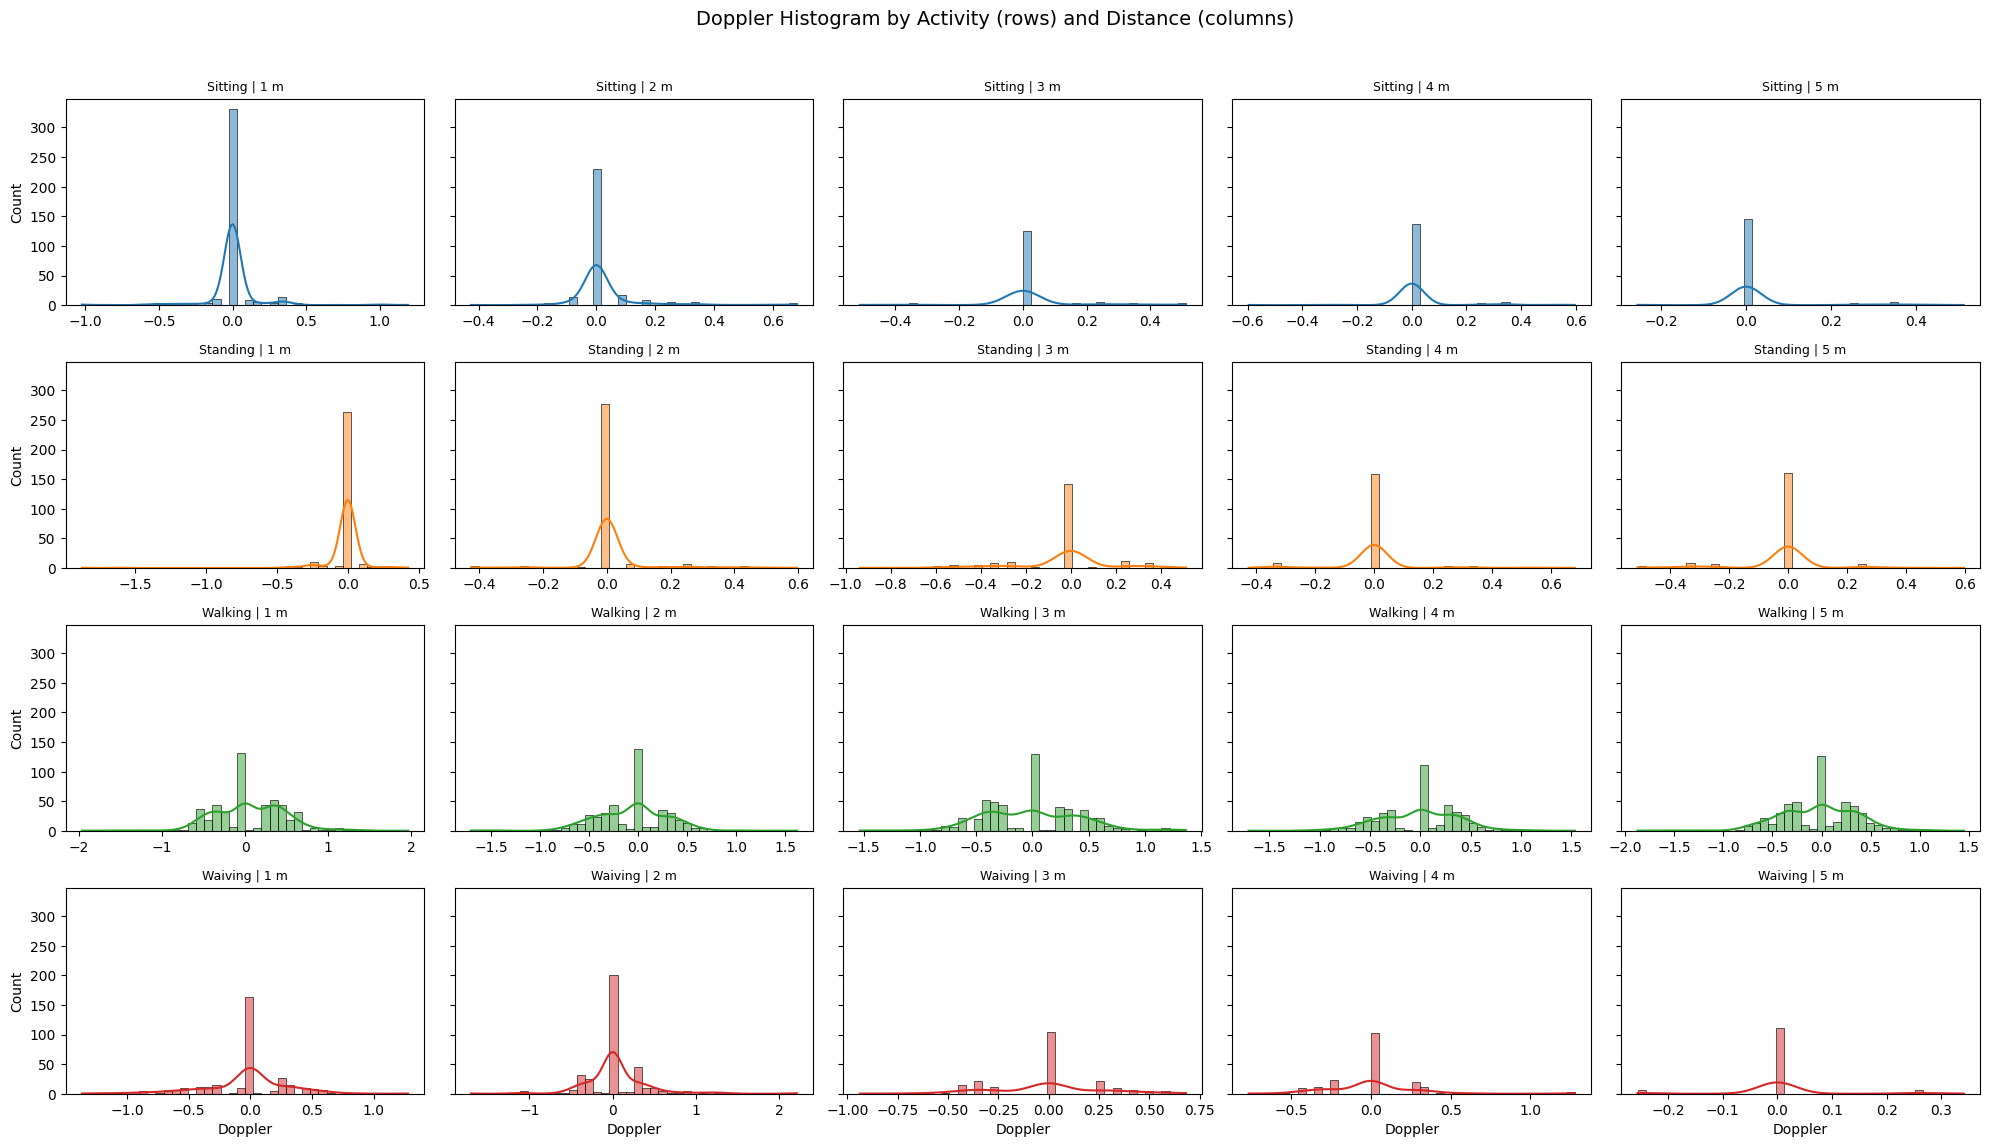

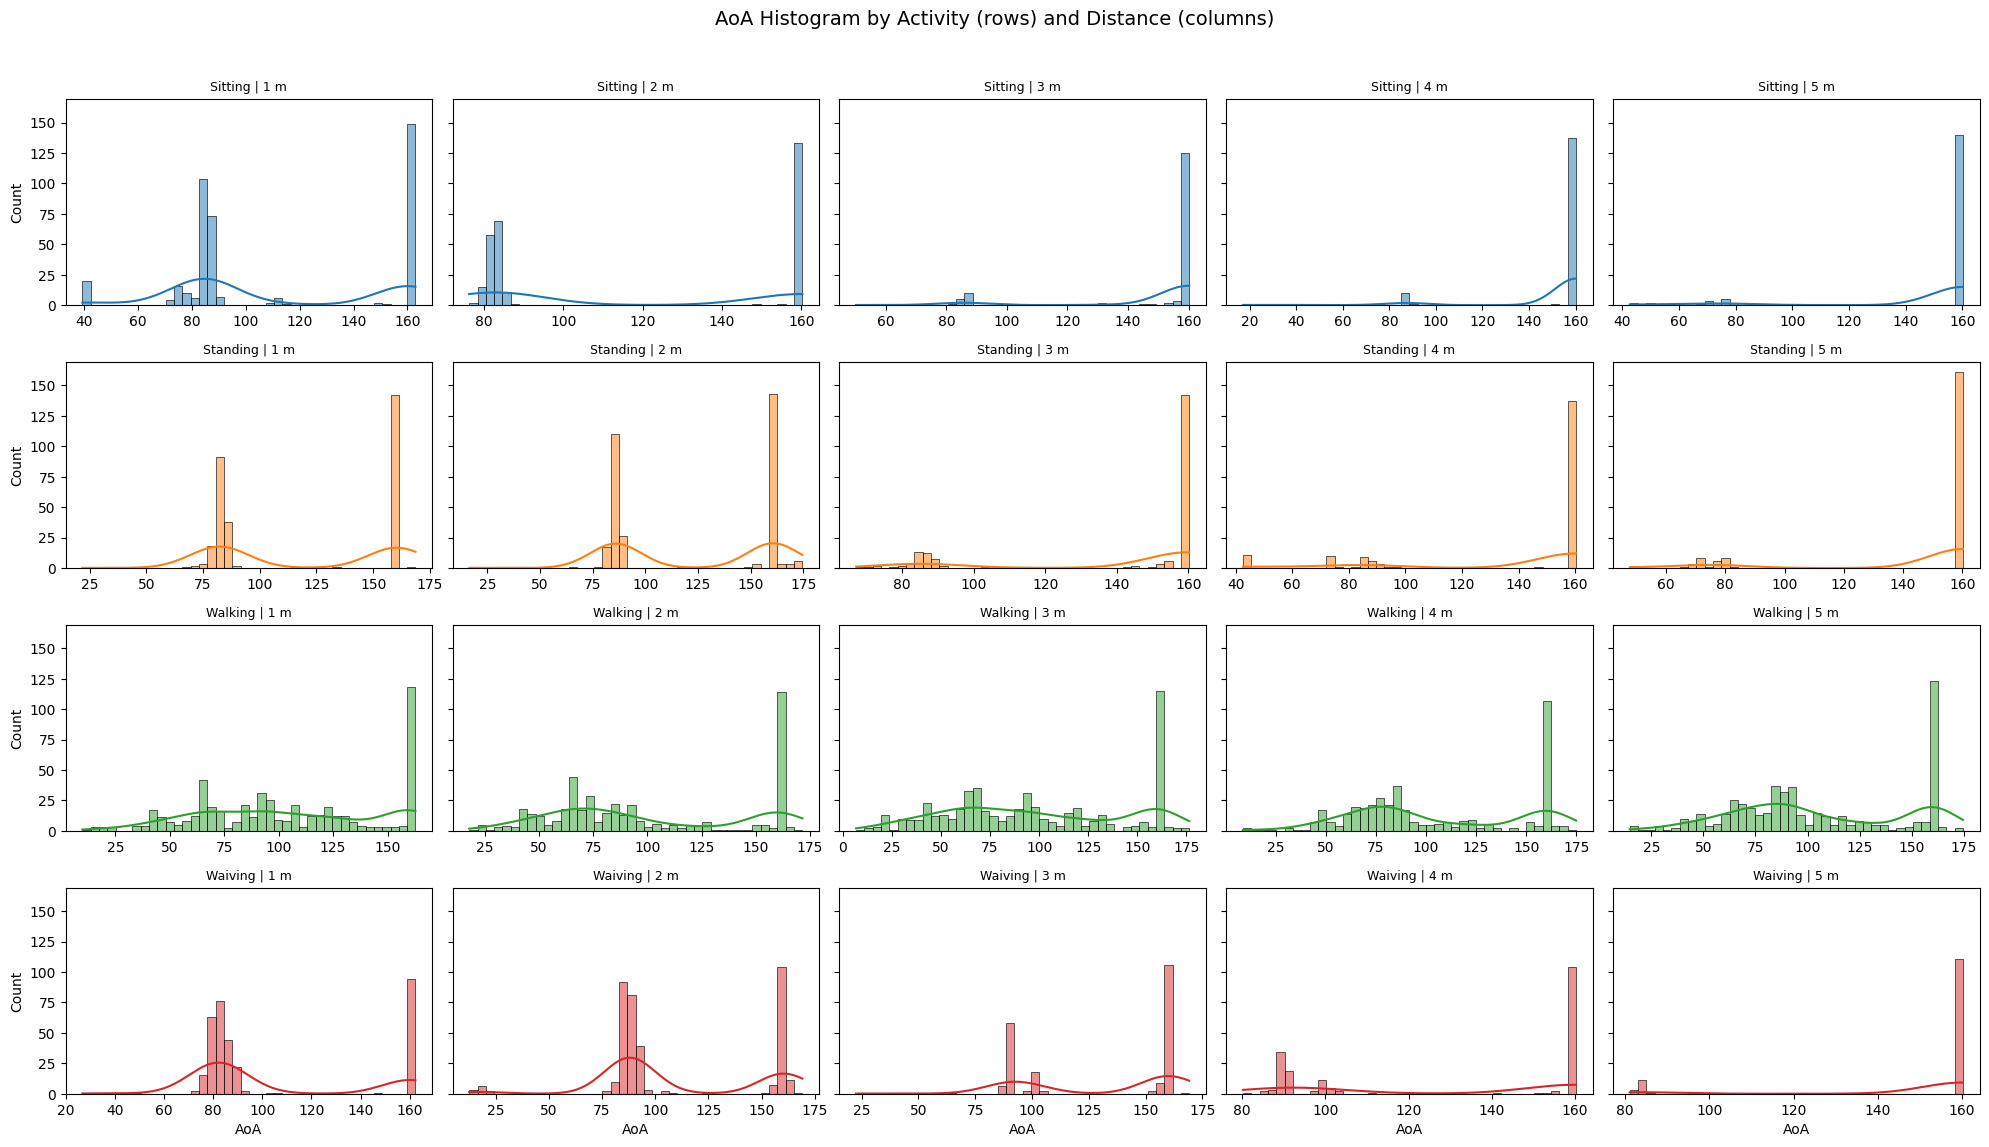

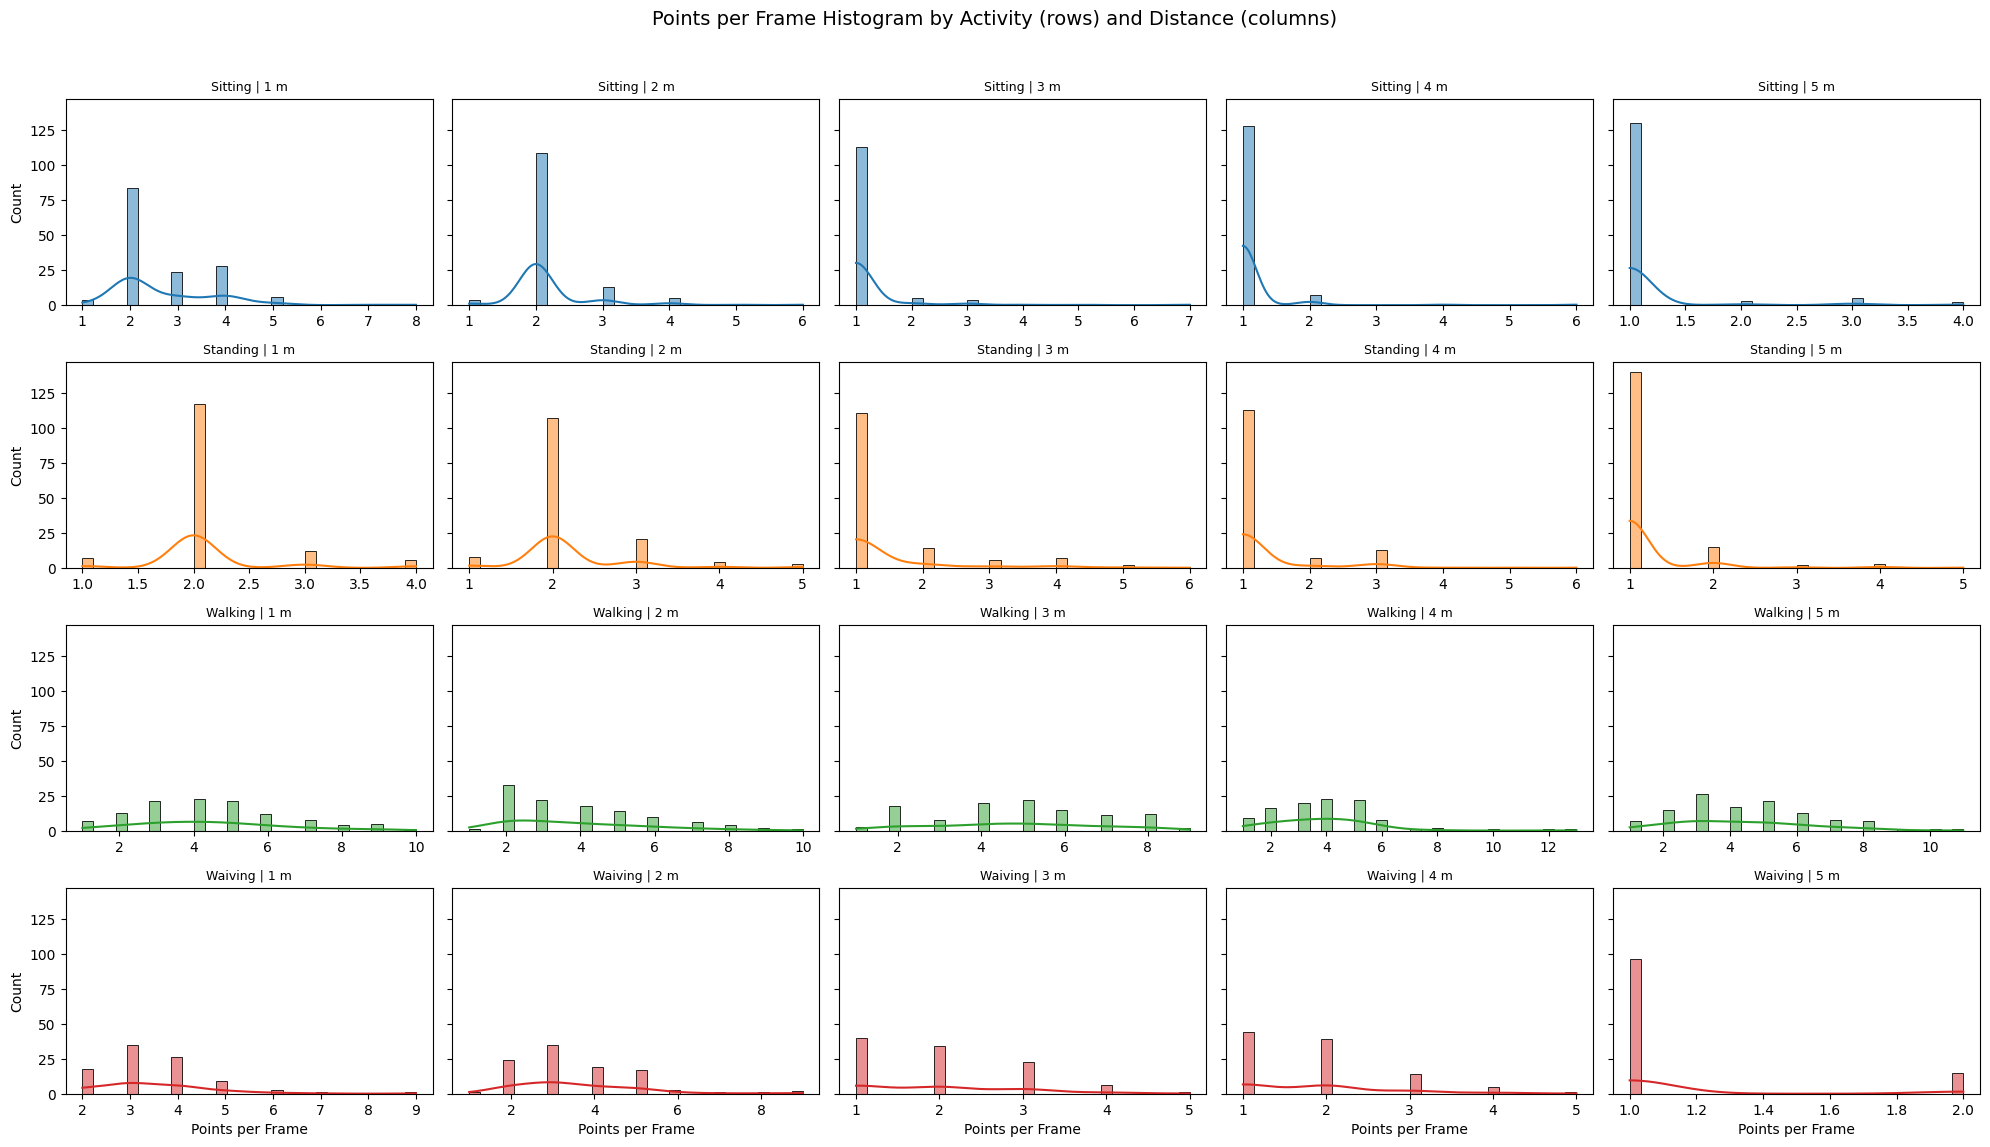

In [16]:
import re
import seaborn as sns
import matplotlib.pyplot as plt


# Build points-per-frame table for the points histogram.
points_per_frame = (
    pointcloud_snr_df
    .groupby(["activity", "sample", "frame_number"])
    .size()
    .reset_index(name="points")
)


# Sort distances numerically (e.g., 1 m, 2 m, 2.5 m, 3 m...).
def distance_sort_key(label):
    m = re.search(r"\d+(?:\.\d+)?", str(label))
    return float(m.group(0)) if m else float("inf")


activities = ["Sitting", "Standing", "Walking", "Waiving"]
all_activities = [a for a in activities if a in pointcloud_snr_df["activity"].unique()]
if not all_activities:
    all_activities = sorted(pointcloud_snr_df["activity"].dropna().unique())

distances = sorted(pointcloud_snr_df["sample"].dropna().unique(), key=distance_sort_key)

activity_colors = {
    "Sitting": "#1f77b4",
    "Standing": "#ff7f0e",
    "Walking": "#2ca02c",
    "Waiving": "#d62728",
}

feature_specs = [
    ("range", "Range", pointcloud_snr_df, 40),
    ("doppler", "Doppler", pointcloud_snr_df, 40),
    ("aoa", "AoA", pointcloud_snr_df, 40),
    ("points", "Points per Frame", points_per_frame, 30),
]

for feature_col, feature_title, source_df, bins in feature_specs:
    fig, axes = plt.subplots(
        len(all_activities),
        len(distances),
        figsize=(4.0 * len(distances), 2.8 * len(all_activities)),
        sharex=False,
        sharey=True,
    )

    if len(all_activities) == 1 and len(distances) == 1:
        axes = [[axes]]
    elif len(all_activities) == 1:
        axes = [axes]
    elif len(distances) == 1:
        axes = [[ax] for ax in axes]

    for i, act in enumerate(all_activities):
        for j, dist in enumerate(distances):
            ax = axes[i][j]
            session_df = source_df[
                (source_df["activity"] == act) &
                (source_df["sample"] == dist)
            ]

            if not session_df.empty:
                sns.histplot(
                    data=session_df,
                    x=feature_col,
                    bins=bins,
                    kde=True,
                    color=activity_colors.get(act, "#333333"),
                    ax=ax,
                )
            else:
                ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)

            ax.set_title(f"{act} | {dist}", fontsize=9)
            if i == len(all_activities) - 1:
                ax.set_xlabel(feature_title)
            else:
                ax.set_xlabel("")

            if j == 0:
                ax.set_ylabel("Count")
            else:
                ax.set_ylabel("")

    plt.suptitle(
        f"{feature_title} Histogram by Activity (rows) and Distance (columns)",
        fontsize=14,
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

- Range provides reliable distance estimation for short targets, become noisy and less consistent at higher distance and during motion.
- Doppler most distinctive, static act. has narrow cluster near zero, wide spread on dynamic cluster
- AoA: narrow cluster on static, wide cluster on dynamic
large distance, aoa become less stable

- point density reflect activity intensity but is strongly affected by distance and signal quality, limiting its standalone reliability 

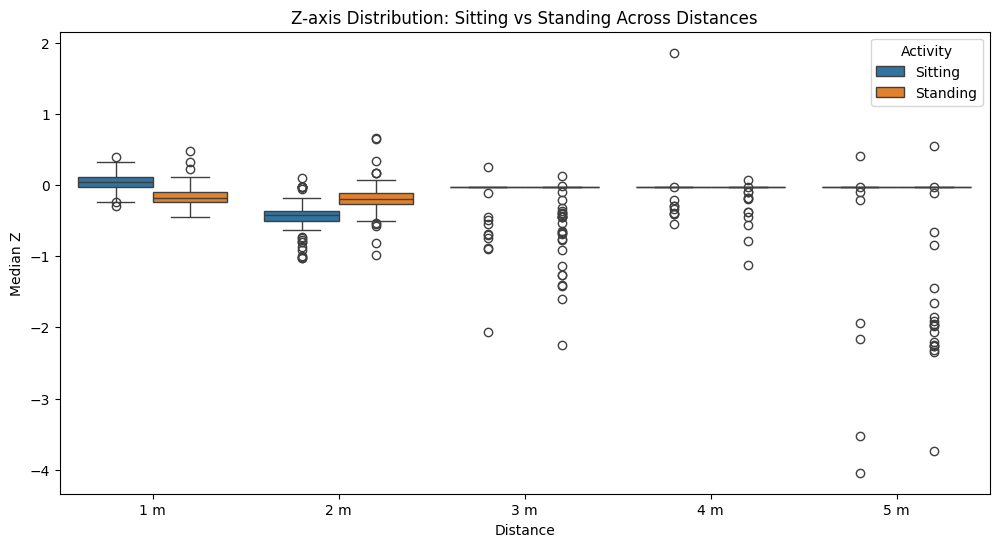

sample,1 m,2 m,3 m,4 m,5 m
activity,,,,,
Sitting,0.040,-0.426,-0.026,-0.026,-0.026
Standing,-0.180,-0.198,-0.026,-0.026,-0.026


In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Only Sitting vs Standing data
ss_df = pointcloud_snr_df[
    pointcloud_snr_df["activity"].isin(["Sitting", "Standing"])
].copy()

# Frame-wise median Z (noise remove)
z_frame = (
    ss_df
    .groupby(["activity", "sample", "frame_number"])["z"]
    .median()
    .reset_index()
)

# Plot 
plt.figure(figsize=(12,6))

sns.boxplot(
    data=z_frame,
    x="sample",        # distance (1m–5m)
    y="z",
    hue="activity"
)

plt.title("Z-axis Distribution: Sitting vs Standing Across Distances")
plt.xlabel("Distance")
plt.ylabel("Median Z")
plt.legend(title="Activity")
plt.show()


# checking median z per session

z_stats = (
    z_frame
    .groupby(["activity","sample"])["z"]
    .median()
    .unstack()
)

display(z_stats)

The boxplot shows the distribution of median Z values for sitting and standing activities across different distances (1m to 5m).

 Observations:
 
- At 1m and 2m, there is a slight difference between sitting and standing, but the distributions still overlap significantly. 

- From 3m to 5m, the median Z values for both sitting and standing converge to nearly the same value.

- A large number of outliers are observed, indicating instability and noise in Z measurements. 

- The spread of values is inconsistent across distances, especially at larger ranges. 

### Insights: 

- The Z-axis does not provide a clear separation between sitting and standing activities in this dataset. 

- The heavy overlap between the two classes suggests that Z alone is not sufficient for posture classification. 


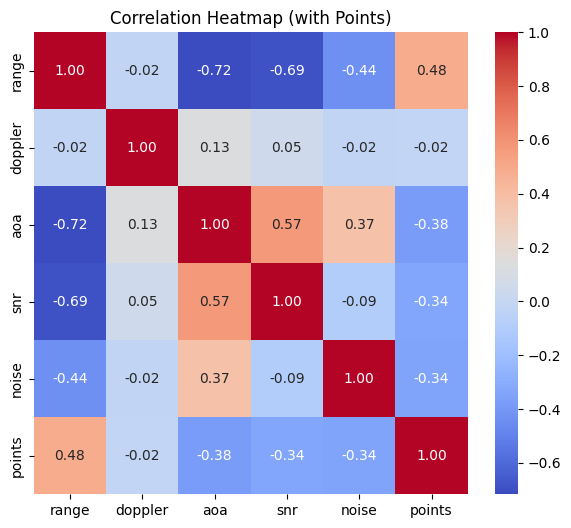

In [18]:
# corelation heatmap of features (range, doppler, aoa, snr, noise, points)

# Merge points into main dataframe
points_per_frame = (
    pointcloud_snr_df
    .groupby(["activity", "sample", "frame_number"])
    .size()
    .reset_index(name="points")
)

# Merge back (optional advanced)
merged_df = pd.merge(
    pointcloud_snr_df,
    points_per_frame,
    on=["activity", "sample", "frame_number"],
    how="left"
)

features = ["range", "doppler", "aoa", "snr", "noise", "points"]

corr_matrix = merged_df[features].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (with Points)")
plt.show()

### Observations:

- **Range vs AoA (-0.72)** shows strong negative correlation, indicating geometric dependency between distance and angle estimation.
- **Range vs SNR (-0.69)** confirms signal attenuation with distance.
- **Range vs Points (0.48)** suggests moderate dependence of detection density on distance.
- **AoA vs SNR (0.57)** indicates angular positions influence signal strength.
- **Doppler has near-zero correlation** with all features, showing independence from spatial and signal characteristics.
- **Points show moderate negative correlation** with AoA, SNR, and noise, indicating density is not directly linked to signal quality.

### Insights:

- **Doppler is a highly independent and discriminative feature** for activity recognition.
- **Range and SNR are strongly coupled**, reflecting physical propagation effects.
- **AoA is influenced by both geometry and signal quality**, not purely independent.
- Low overall correlation indicates **features are complementary**, supporting multi-feature fusion for robust modeling.

Explained variance by PCA components: [0.46506549 0.18894342]


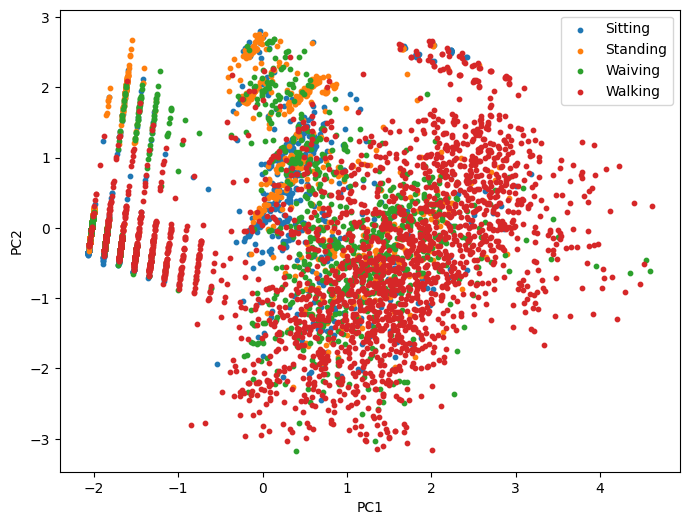

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

points_per_frame = (
    pointcloud_snr_df
    .groupby(["activity", "sample", "frame_number"])
    .size()
    .reset_index(name="points")
)
merged_df = pd.merge(
    pointcloud_snr_df,
    points_per_frame,
    on=["activity", "sample", "frame_number"],
    how="left"
)
features = ["range", "doppler", "aoa", "snr", "noise", "points"]
X = merged_df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance by PCA components: {pca.explained_variance_ratio_}") 


plt.figure(figsize=(8,6))
for act in merged_df.loc[X.index, "activity"].unique():
    idx = merged_df.loc[X.index, "activity"] == act
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=act, s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

KMeans Silhouette Score: 0.435


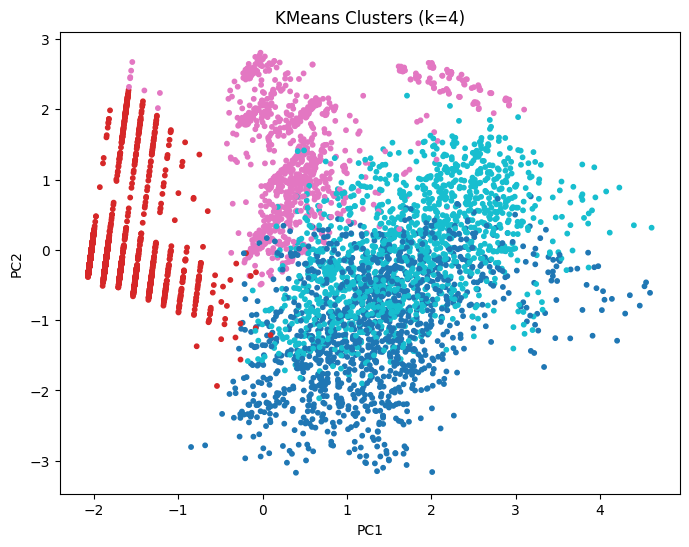

Cluster distribution by activity:
col_0       0    1    2    3
activity                    
Sitting    92  685  340   38
Standing   71  718  306   97
Waiving   257  511  190  253
Walking   813  566  160  857


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, labels)
print(f"KMeans Silhouette Score: {sil_score:.3f}")


plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap="tab10", s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clusters (k={k})")
plt.show()

ct = pd.crosstab(merged_df.loc[X.index, "activity"], labels)
print("Cluster distribution by activity:")
print(ct)

PCA: Total 65% data is captured in 2D space
- sitting and standing are overlapping:static, walking spread: high variability in motion

k-means silhoustte .45: moderate cluster seperation
- clusters arent perfectly align with activity labels



Taking snr mean to get the avg spread over the frames gives more meaningful information

### Using Raw PointCloudsnr feature

In [21]:
import pandas as pd
import numpy as np

df = pointcloud_snr_df.copy()

print(df.shape)
display(df.head())

(5954, 13)


,activity,sample,timestamp_s,frame_number,point_index,x,y,z,doppler,range,aoa,snr,noise
0,Sitting,1 m,0.000,1,0,-0.116,0.042,-0.026,0.000,0.126,160.195,21.800,66.800
1,Sitting,1 m,0.000,1,1,0.139,1.499,0.062,0.000,1.507,84.712,17.600,65.300
2,Sitting,1 m,0.000,1,2,-0.648,1.548,-0.526,-1.023,1.758,112.704,19.800,41.600
3,Sitting,1 m,0.000,1,3,0.000,1.259,1.227,-1.023,1.758,90.000,19.800,41.600
4,Sitting,1 m,0.297,2,0,-0.116,0.042,-0.026,0.000,0.126,160.198,18.900,69.700


In [22]:
feature_cols = ["x", "y", "z", "doppler", "aoa", "snr", "noise"]

needed_cols = ["activity", "sample", "frame_number"] + feature_cols
df = df[needed_cols].copy()

df = df.dropna(subset=feature_cols).reset_index(drop=True)

print(df.shape)
display(df.head())

(5954, 10)


,activity,sample,frame_number,x,y,z,doppler,aoa,snr,noise
0,Sitting,1 m,1,-0.116,0.042,-0.026,0.000,160.195,21.800,66.800
1,Sitting,1 m,1,0.139,1.499,0.062,0.000,84.712,17.600,65.300
2,Sitting,1 m,1,-0.648,1.548,-0.526,-1.023,112.704,19.800,41.600
3,Sitting,1 m,1,0.000,1.259,1.227,-1.023,90.000,19.800,41.600
4,Sitting,1 m,2,-0.116,0.042,-0.026,0.000,160.198,18.900,69.700


In [23]:
df["session_id"] = df["activity"].astype(str) + "_" + df["sample"].astype(str)

print(df[["activity", "sample", "session_id"]].drop_duplicates().head(20))

      activity sample    session_id
0      Sitting    1 m   Sitting_1 m
401    Sitting    2 m   Sitting_2 m
693    Sitting    3 m   Sitting_3 m
844    Sitting    4 m   Sitting_4 m
996    Sitting    5 m   Sitting_5 m
1155  Standing    1 m  Standing_1 m
1456  Standing    2 m  Standing_2 m
1772  Standing    3 m  Standing_3 m
1973  Standing    4 m  Standing_4 m
2154  Standing    5 m  Standing_5 m
2347   Waiving    1 m   Waiving_1 m
2671   Waiving    2 m   Waiving_2 m
3037   Waiving    3 m   Waiving_3 m
3243   Waiving    4 m   Waiving_4 m
3432   Waiving    5 m   Waiving_5 m
3558   Walking    1 m   Walking_1 m
4066   Walking    2 m   Walking_2 m
4503   Walking    3 m   Walking_3 m
5037   Walking    4 m   Walking_4 m
5446   Walking    5 m   Walking_5 m


In [24]:
# adding a new column for session ID
df = df.sort_values(["activity", "sample", "frame_number"]).reset_index(drop=True)

print(df.shape)
display(df.head())

(5954, 11)


,activity,sample,frame_number,x,y,z,doppler,aoa,snr,noise,session_id
0,Sitting,1 m,1,-0.116,0.042,-0.026,0.000,160.195,21.800,66.800,Sitting_1 m
1,Sitting,1 m,1,0.139,1.499,0.062,0.000,84.712,17.600,65.300,Sitting_1 m
2,Sitting,1 m,1,-0.648,1.548,-0.526,-1.023,112.704,19.800,41.600,Sitting_1 m
3,Sitting,1 m,1,0.000,1.259,1.227,-1.023,90.000,19.800,41.600,Sitting_1 m
4,Sitting,1 m,2,-0.116,0.042,-0.026,0.000,160.198,18.900,69.700,Sitting_1 m


In [25]:
points_per_frame = (
    df.groupby(["activity", "session_id", "frame_number"])
      .size()
      .reset_index(name="num_points")
)

print("Point count per frame summary:")
display(points_per_frame.head(20))
display(points_per_frame["num_points"].describe())

Point count per frame summary:


,activity,session_id,frame_number,num_points
0,Sitting,Sitting_1 m,1,4
1,Sitting,Sitting_1 m,2,2
2,Sitting,Sitting_1 m,3,4
3,Sitting,Sitting_1 m,4,2
4,Sitting,Sitting_1 m,5,2
5,Sitting,Sitting_1 m,6,4
6,Sitting,Sitting_1 m,7,4
7,Sitting,Sitting_1 m,8,2
8,Sitting,Sitting_1 m,9,1
9,Sitting,Sitting_1 m,10,8


count   2478.000
mean       2.403
std        1.724
min        1.000
25%        1.000
50%        2.000
75%        3.000
max       13.000
Name: num_points, dtype: float64

convert your raw variable-length point cloud per frame into a fixed-size tensor per frame so a deep model can use it

In [26]:
MAX_POINTS = 32   # choose fixed number of points per frame

def build_frame_tensor_raw(df, feature_cols, max_points=32):
    frame_tensors = []
    frame_meta = []

    grouped = df.groupby(["activity", "sample", "session_id", "frame_number"])

    for (act, samp, sess, frame_no), g in grouped:
        g = g.sort_values(by=g.columns.tolist()).reset_index(drop=True)

        pts = g[feature_cols].values.astype(np.float32)

        frame_array = np.zeros((max_points, len(feature_cols)), dtype=np.float32)

        n = min(len(pts), max_points)
        frame_array[:n] = pts[:n]

        frame_tensors.append(frame_array)
        frame_meta.append({
            "activity": act,
            "sample": samp,
            "session_id": sess,
            "frame_number": int(frame_no),
            "num_points_original": len(pts),
            "num_points_used": n
        })

    frame_tensors = np.array(frame_tensors, dtype=np.float32)
    frame_meta = pd.DataFrame(frame_meta)

    return frame_tensors, frame_meta

frame_tensors, frame_meta = build_frame_tensor_raw(df, feature_cols, max_points=MAX_POINTS)

print("frame_tensors shape:", frame_tensors.shape)
display(frame_meta.head())

frame_tensors shape: (2478, 32, 7)


,activity,sample,session_id,frame_number,num_points_original,num_points_used
0,Sitting,1 m,Sitting_1 m,1,4,4
1,Sitting,1 m,Sitting_1 m,2,2,2
2,Sitting,1 m,Sitting_1 m,3,4,4
3,Sitting,1 m,Sitting_1 m,4,2,2
4,Sitting,1 m,Sitting_1 m,5,2,2


In [27]:
session_frame_counts = (
    frame_meta.groupby(["activity", "session_id"])
    .size()
    .reset_index(name="num_frames")
    .sort_values(["activity", "session_id"])
)

display(session_frame_counts)

,activity,session_id,num_frames
0,Sitting,Sitting_1 m,148
1,Sitting,Sitting_2 m,133
2,Sitting,Sitting_3 m,125
3,Sitting,Sitting_4 m,137
4,Sitting,Sitting_5 m,140
5,Standing,Standing_1 m,142
6,Standing,Standing_2 m,143
7,Standing,Standing_3 m,141
8,Standing,Standing_4 m,136
9,Standing,Standing_5 m,161


In [28]:
#Creating your final model samples from the frame tensors
SEQ_LEN = 30
STEP = 10

def build_sequences_from_raw_frames(frame_tensors, frame_meta, seq_len=30, step=10):
    X, y, meta = [], [], []

    for (act, samp, sess), g_meta in frame_meta.groupby(["activity", "sample", "session_id"]):
        g_meta = g_meta.sort_values("frame_number").reset_index(drop=True)

        idx = g_meta.index.to_numpy()
        frames = frame_tensors[idx]

        if len(frames) < seq_len:
            continue

        for i in range(0, len(frames) - seq_len + 1, step):
            seq = frames[i:i+seq_len]

            X.append(seq)
            y.append(act)
            meta.append({
                "activity": act,
                "sample": samp,
                "session_id": sess,
                "start_frame": int(g_meta.iloc[i]["frame_number"]),
                "end_frame": int(g_meta.iloc[i+seq_len-1]["frame_number"])
            })

    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    meta = pd.DataFrame(meta)

    return X, y, meta

X_seq, y_seq, meta = build_sequences_from_raw_frames(
    frame_tensors, frame_meta, seq_len=SEQ_LEN, step=STEP
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("meta shape :", meta.shape)
display(meta.head())

X_seq shape: (201, 30, 32, 7)
y_seq shape: (201,)
meta shape : (201, 5)


,activity,sample,session_id,start_frame,end_frame
0,Sitting,1 m,Sitting_1 m,1,30
1,Sitting,1 m,Sitting_1 m,11,40
2,Sitting,1 m,Sitting_1 m,21,50
3,Sitting,1 m,Sitting_1 m,31,60
4,Sitting,1 m,Sitting_1 m,41,70


In [29]:
np.random.seed(42)

train_sessions = []
test_sessions = []

for act in sorted(meta["activity"].unique()):
    act_sessions = sorted(meta.loc[meta["activity"] == act, "session_id"].unique())

    chosen_train = np.random.choice(act_sessions, size=3, replace=False)
    chosen_test = [s for s in act_sessions if s not in chosen_train]

    train_sessions.extend(chosen_train)
    test_sessions.extend(chosen_test)

print("Train sessions:", sorted(train_sessions))
print("Test sessions :", sorted(test_sessions))

Train sessions: ['Sitting_2 m', 'Sitting_3 m', 'Sitting_5 m', 'Standing_2 m', 'Standing_3 m', 'Standing_4 m', 'Waiving_1 m', 'Waiving_2 m', 'Waiving_4 m', 'Walking_1 m', 'Walking_2 m', 'Walking_3 m']
Test sessions : ['Sitting_1 m', 'Sitting_4 m', 'Standing_1 m', 'Standing_5 m', 'Waiving_3 m', 'Waiving_5 m', 'Walking_4 m', 'Walking_5 m']


In [30]:
train_mask = meta["session_id"].isin(train_sessions)
test_mask = meta["session_id"].isin(test_sessions)

X_train = X_seq[train_mask.to_numpy()]
X_test  = X_seq[test_mask.to_numpy()]

y_train = y_seq[train_mask.to_numpy()]
y_test  = y_seq[test_mask.to_numpy()]

meta_train = meta[train_mask].reset_index(drop=True)
meta_test  = meta[test_mask].reset_index(drop=True)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (118, 30, 32, 7)
X_test shape : (83, 30, 32, 7)
y_train shape: (118,)
y_test shape : (83,)


In [31]:
print(X_train[0])

[[[-6.47506893e-01  1.54758906e+00 -5.25522411e-01 ...  1.12704300e+02
    1.97999992e+01  4.15999985e+01]
  [-1.15626231e-01  4.16399427e-02 -2.57759262e-02 ...  1.60194763e+02
    2.17999992e+01  6.68000031e+01]
  [ 0.00000000e+00  1.25906646e+00  1.22687519e+00 ...  9.00000000e+01
    1.97999992e+01  4.15999985e+01]
  ...
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]]

 [[-1.15626231e-01  4.16317843e-02 -2.57891007e-02 ...  1.60198349e+02
    1.88999996e+01  6.96999969e+01]
  [ 1.38751492e-01  1.49998605e+00  3.66058722e-02 ...  8.47150726e+01
    2.22000008e+01  6.55000000e+01]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
    0.00000000e+00  0.00000000e+00]
  ...
  [ 0.00000000e+00  0.0

Finlally, how data is feeding into ML:
118 = total number of training sequences
30 = each sequence contains 30 consecutive frames
32 = each frame is stored with space for 32 points
7 = each point has 7 raw features

In [32]:
train_session_table = (
    meta_train.groupby(["activity", "session_id"])
    .size()
    .reset_index(name="num_sequences")
    .sort_values(["activity", "session_id"])
)

train_activity_total = (
    train_session_table.groupby("activity")["num_sequences"]
    .sum()
    .reset_index(name="total_sequences_train")
)

train_final_table = train_session_table.merge(
    train_activity_total, on="activity", how="left"
)

print("TRAIN DATA")
display(train_final_table)

test_session_table = (
    meta_test.groupby(["activity", "session_id"])
    .size()
    .reset_index(name="num_sequences")
    .sort_values(["activity", "session_id"])
)

test_activity_total = (
    test_session_table.groupby("activity")["num_sequences"]
    .sum()
    .reset_index(name="total_sequences_test")
)

test_final_table = test_session_table.merge(
    test_activity_total, on="activity", how="left"
)

print("TEST DATA")
display(test_final_table)

summary_table = train_activity_total.merge(
    test_activity_total, on="activity", how="outer"
)

print("SUMMARY")
display(summary_table)

TRAIN DATA


,activity,session_id,num_sequences,total_sequences_train
0,Sitting,Sitting_2 m,11,33
1,Sitting,Sitting_3 m,10,33
2,Sitting,Sitting_5 m,12,33
3,Standing,Standing_2 m,12,35
4,Standing,Standing_3 m,12,35
5,Standing,Standing_4 m,11,35
6,Waiving,Waiving_1 m,7,23
7,Waiving,Waiving_2 m,8,23
8,Waiving,Waiving_4 m,8,23
9,Walking,Walking_1 m,9,27


TEST DATA


,activity,session_id,num_sequences,total_sequences_test
0,Sitting,Sitting_1 m,12,23
1,Sitting,Sitting_4 m,11,23
2,Standing,Standing_1 m,12,26
3,Standing,Standing_5 m,14,26
4,Waiving,Waiving_3 m,8,17
5,Waiving,Waiving_5 m,9,17
6,Walking,Walking_4 m,8,17
7,Walking,Walking_5 m,9,17


SUMMARY


,activity,total_sequences_train,total_sequences_test
0,Sitting,33,23
1,Standing,35,26
2,Waiving,23,17
3,Walking,27,17


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['Sitting' 'Standing' 'Waiving' 'Walking']


In [34]:
N_train, T, P, F = X_train.shape
N_test = X_test.shape[0]

X_train_flat = X_train.reshape(N_train, T, P * F)
X_test_flat  = X_test.reshape(N_test, T, P * F)

print("X_train_flat shape:", X_train_flat.shape)
print("X_test_flat shape :", X_test_flat.shape)

X_train_flat shape: (118, 30, 224)
X_test_flat shape : (83, 30, 224)


Making adjustment to CNN/LSTM model parameter

In [35]:
from sklearn.preprocessing import StandardScaler

n_train, seq_len, n_feat = X_train_flat.shape
n_test = X_test_flat.shape[0]

X_train_2d = X_train_flat.reshape(-1, n_feat)
X_test_2d  = X_test_flat.reshape(-1, n_feat)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_2d)
X_test_scaled  = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled.reshape(n_train, seq_len, n_feat)
X_test_scaled  = X_test_scaled.reshape(n_test, seq_len, n_feat)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (118, 30, 224)
X_test_scaled shape : (83, 30, 224)


In [36]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (118, 30, 32, 7)
X_test shape : (83, 30, 32, 7)
y_train shape: (118,)
y_test shape : (83,)


In [37]:
# Encode labels to integers
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [38]:
from sklearn.preprocessing import StandardScaler
import numpy as np

N_train, T, P, F = X_train.shape
N_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, F)
X_test_2d  = X_test.reshape(-1, F)

scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)
X_test_scaled_2d  = scaler.transform(X_test_2d)

X_train_scaled = X_train_scaled_2d.reshape(N_train, T, P, F)
X_test_scaled  = X_test_scaled_2d.reshape(N_test, T, P, F)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

X_train_scaled shape: (118, 30, 32, 7)
X_test_scaled shape : (83, 30, 32, 7)


This step is adding a channel dimension so your data becomes compatible with Conv2D inside TimeDistributed (3D CNN-LSTM)

In [39]:
X_train_5d = X_train_scaled[..., np.newaxis]
X_test_5d  = X_test_scaled[..., np.newaxis]

print("X_train_5d shape:", X_train_5d.shape)
print("X_test_5d shape :", X_test_5d.shape)

X_train_5d shape: (118, 30, 32, 7, 1)
X_test_5d shape : (83, 30, 32, 7, 1)


In [40]:
print("One sample shape:", X_train_5d[0].shape)
print("One label:", y_train[0], "->", y_train_enc[0])
print(X_train_5d[0][0])   # first frame of first sample

One sample shape: (30, 32, 7, 1)
One label: Sitting -> 0
[[[-4.0808806e+00]
  [ 3.2687707e+00]
  [-3.1942904e+00]
  [-2.0743069e+01]
  [ 3.1089530e+00]
  [ 2.5291610e+00]
  [ 2.4119740e+00]]

 [[-7.4591702e-01]
  [-1.2443345e-01]
  [-1.6615695e-01]
  [-3.0915251e-02]
  [ 4.5378056e+00]
  [ 2.8133092e+00]
  [ 4.0513067e+00]]

 [[-2.0925015e-02]
  [ 2.6186717e+00]
  [ 7.4240818e+00]
  [-2.0743069e+01]
  [ 2.4258451e+00]
  [ 2.5291610e+00]
  [ 2.4119740e+00]]

 [[ 8.4906554e-01]
  [ 3.1596286e+00]
  [ 3.6581075e-01]
  [-3.0915251e-02]
  [ 2.2667487e+00]
  [ 2.2165983e+00]
  [ 3.9537275e+00]]

 [[-2.0925015e-02]
  [-2.1825656e-01]
  [-9.9718459e-03]
  [-3.0915251e-02]
  [-2.8199822e-01]
  [-2.8390533e-01]
  [-2.9422545e-01]]

 [[-2.0925015e-02]
  [-2.1825656e-01]
  [-9.9718459e-03]
  [-3.0915251e-02]
  [-2.8199822e-01]
  [-2.8390533e-01]
  [-2.9422545e-01]]

 [[-2.0925015e-02]
  [-2.1825656e-01]
  [-9.9718459e-03]
  [-3.0915251e-02]
  [-2.8199822e-01]
  [-2.8390533e-01]
  [-2.9422545e-01]]

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, MaxPooling2D, Flatten,
    LSTM, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping

num_classes = len(le.classes_)
input_shape = X_train_5d.shape[1:]   # (SEQ_LEN, MAX_POINTS, NUM_FEATURES, 1)

model_3dcnn_lstm = Sequential([
    TimeDistributed(
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        input_shape=input_shape
    ),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(
        Conv2D(64, (3, 3), activation='relu', padding='same')
    ),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D((2, 2))),

    TimeDistributed(Flatten()),

    LSTM(64, return_sequences=False),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

model_3dcnn_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_3dcnn_lstm.summary()

c:\Users\14052\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 32, 7, 32)  │           320 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 32, 7, 32)  │           128 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 30, 16, 3, 32)  │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 16, 3, 64)  │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 30, 16, 3, 64)  │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 30, 8, 1, 64)   │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 30, 512)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,332 (669.27 KB)

 Trainable params: 171,140 (668.52 KB)

 Non-trainable params: 192 (768.00 B)

Early stopping stops training when validation performance stops improving to prevent overfitting and keep the best model

In [42]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model_3dcnn_lstm.fit(
    X_train_5d, y_train_enc,
    validation_data=(X_test_5d, y_test_enc),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 385ms/step - accuracy: 0.2724 - loss: 1.4346 - val_accuracy: 0.3012 - val_loss: 1.3731
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 198ms/step - accuracy: 0.2074 - loss: 1.4574 - val_accuracy: 0.3133 - val_loss: 1.3728
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 199ms/step - accuracy: 0.3255 - loss: 1.3473 - val_accuracy: 0.3012 - val_loss: 1.3668
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 201ms/step - accuracy: 0.3021 - loss: 1.4226 - val_accuracy: 0.3133 - val_loss: 1.3623
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.2465 - loss: 1.4511 - val_accuracy: 0.3133 - val_loss: 1.3648
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 196ms/step - accuracy: 0.2363 - loss: 1.3659 - val_accuracy: 0.3012 - val_loss: 1.3653
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.2555 - loss: 1.4092 - val_accuracy: 0.2892 - val_loss: 1.3655
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 192ms/step - accuracy: 0.3351 - loss: 1.3341 - val_accuracy: 0

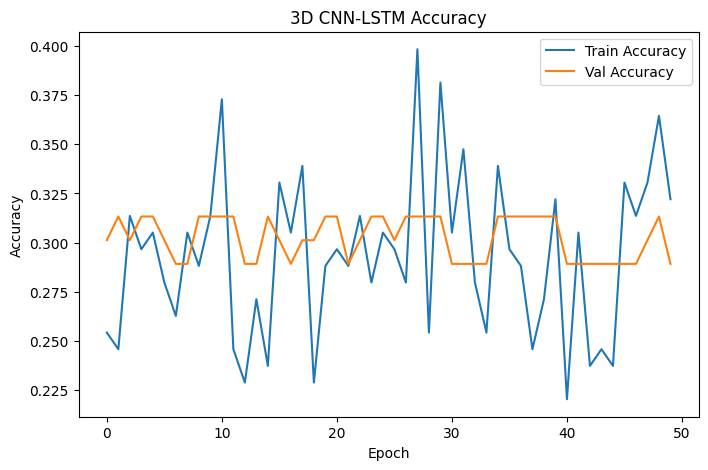

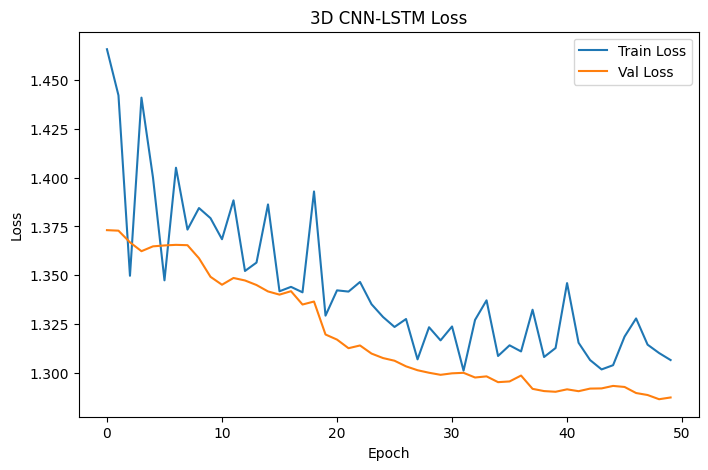

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('3D CNN-LSTM Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('3D CNN-LSTM Loss')
plt.legend()
plt.show()

In [44]:
test_loss, test_acc = model_3dcnn_lstm.evaluate(X_test_5d, y_test_enc, verbose=0)

print("Test Loss :", test_loss)
print("Test Acc  :", test_acc)

Test Loss : 1.2864023447036743
Test Acc  : 0.3132530152797699


In [45]:
from sklearn.metrics import classification_report

print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

NameError: name 'y_pred' is not defined

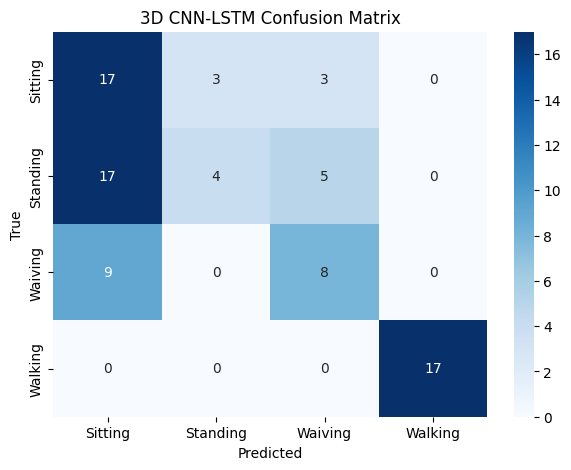

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("3D CNN-LSTM Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

pred_df = meta_test.copy()
pred_df["true_label"] = y_test
pred_df["true_enc"] = y_test_enc
pred_df["pred_enc"] = y_pred
pred_df["pred_label"] = le.inverse_transform(y_pred)

print("\nTEST SEQUENCES PER SESSION")
display(
    pred_df.groupby(["activity", "session_id"])
    .size()
    .reset_index(name="num_sequences")
    .sort_values(["activity", "session_id"])
)

print("\nTEST SEQUENCES PER ACTIVITY")
display(
    pred_df.groupby("true_label")
    .size()
    .reset_index(name="total_test_sequences")
    .sort_values("true_label")
)

print("\nMISCLASSIFIED SEQUENCES")
wrong_df = pred_df[pred_df["true_enc"] != pred_df["pred_enc"]].copy()
display(
    wrong_df[[
        "activity", "sample", "session_id",
        "start_frame", "end_frame",
        "true_label", "pred_label"
    ]].sort_values(["activity", "session_id", "start_frame"])
)


TEST SEQUENCES PER SESSION


,activity,session_id,num_sequences
0,Sitting,Sitting_1 m,12
1,Sitting,Sitting_4 m,11
2,Standing,Standing_1 m,12
3,Standing,Standing_5 m,14
4,Waiving,Waiving_3 m,8
5,Waiving,Waiving_5 m,9
6,Walking,Walking_4 m,8
7,Walking,Walking_5 m,9



TEST SEQUENCES PER ACTIVITY


,true_label,total_test_sequences
0,Sitting,23
1,Standing,26
2,Waiving,17
3,Walking,17



MISCLASSIFIED SEQUENCES


,activity,sample,session_id,start_frame,end_frame,true_label,pred_label
0,Sitting,1 m,Sitting_1 m,1,30,Sitting,Waiving
1,Sitting,1 m,Sitting_1 m,11,40,Sitting,Waiving
2,Sitting,1 m,Sitting_1 m,21,50,Sitting,Waiving
9,Sitting,1 m,Sitting_1 m,91,120,Sitting,Standing
10,Sitting,1 m,Sitting_1 m,101,130,Sitting,Standing
11,Sitting,1 m,Sitting_1 m,111,140,Sitting,Standing
23,Standing,1 m,Standing_1 m,1,30,Standing,Sitting
24,Standing,1 m,Standing_1 m,11,40,Standing,Sitting
25,Standing,1 m,Standing_1 m,21,50,Standing,Waiving
26,Standing,1 m,Standing_1 m,31,60,Standing,Waiving
